# TP4 - Taller de Programación UBA

## Grupo 2 - Clasificando informales en la EPH: Métodos de Regularización & CART

Este trabajo continúa la construcción realizada en el TP3 y utiliza la base `ocupados_X_2025_MM` y la variable objetivo `y_2025`, incorporando el rezago `y_2024`, para comparar Logit sin penalización, LASSO, Ridge y CART.

In [10]:
# ============================================================
# Celda 1 - Instalación e importación de paquetes
# ============================================================

!pip -q install openpyxl

import os
import glob
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    classification_report
)

import statsmodels.api as sm

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 150)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

sns.set_theme(style="whitegrid")

print("Paquetes cargados correctamente.")


Paquetes cargados correctamente.


In [11]:
# ============================================================
# Celda 2 - Conexión a Drive y rutas de trabajo
# ============================================================

from google.colab import drive
drive.mount("/content/drive", force_remount=True)

# Ajustar esta ruta si los archivos están en otra carpeta.
ruta_drive = "/content/drive/MyDrive/taller_de_programacion/"

archivo_2024 = "/content/Taller_de_Programacion_UBA/TP3/salidas/usu_individual_T424.xlsx"
archivo_2025 = "/content/Taller_de_Programacion_UBA/TP3/salidas/usu_individual_T425.xlsx"

ruta_salidas = ruta_drive + "salidas_tp4/"
ruta_figuras = ruta_salidas + "figuras/"
ruta_tablas = ruta_salidas + "tablas/"

os.makedirs(ruta_salidas, exist_ok=True)
os.makedirs(ruta_figuras, exist_ok=True)
os.makedirs(ruta_tablas, exist_ok=True)

print("Ruta de entrada:", ruta_drive)
print("Ruta de salida:", ruta_salidas)

%cd /content

!git clone https://github.com/achasinavas/Taller_de_Programacion_UBA.git
%cd /content/Taller_de_Programacion_UBA


Mounted at /content/drive
Ruta de entrada: /content/drive/MyDrive/taller_de_programacion/
Ruta de salida: /content/drive/MyDrive/taller_de_programacion/salidas_tp4/
/content
fatal: destination path 'Taller_de_Programacion_UBA' already exists and is not an empty directory.
/content/Taller_de_Programacion_UBA


In [12]:
import os

print("Archivo 2024 existe:", os.path.exists(archivo_2024))
print("Ruta 2024:", archivo_2024)

print("Archivo 2025 existe:", os.path.exists(archivo_2025))
print("Ruta 2025:", archivo_2025)

Archivo 2024 existe: True
Ruta 2024: /content/Taller_de_Programacion_UBA/TP3/salidas/usu_individual_T424.xlsx
Archivo 2025 existe: True
Ruta 2025: /content/Taller_de_Programacion_UBA/TP3/salidas/usu_individual_T425.xlsx


In [13]:
# ============================================================
# Celda 3 - Carga de bases EPH
# ============================================================

eph24 = pd.read_excel(archivo_2024)
eph25 = pd.read_excel(archivo_2025)

# Normalizar nombres de columnas
eph24.columns = eph24.columns.astype(str).str.strip().str.upper()
eph25.columns = eph25.columns.astype(str).str.strip().str.upper()

print("Base 2024:", eph24.shape)
print("Base 2025:", eph25.shape)

display(eph24.head())


Base 2024: (46860, 235)
Base 2025: (43703, 235)


,CODUSU,ANO4,TRIMESTRE,NRO_HOGAR,COMPONENTE,H15,REGION,MAS_500,AGLOMERADO,PONDERA,CH03,CH04,CH05,CH06,CH07,CH08,CH09,CH10,CH11,CH12,CH13,CH14,CH15,CH15_COD,CH16,CH16_COD,NIVEL_ED,ESTADO,CAT_OCUP,CAT_INAC,IMPUTA,PP02C1,PP02C2,PP02C3,PP02C4,PP02C5,PP02C6,PP02C7,PP02C8,PP02E,PP02H,PP02I,PP03C,PP03D,PP3E_TOT,PP3F_TOT,PP03G,PP03H,PP03I,PP03J,INTENSI,PP04A,PP04B_COD,PP04B1,PP04B2,PP04B3_MES,PP04B3_ANO,PP04B3_DIA,PP04C,PP04C99,PP04D_COD,PP04G,PP05B2_MES,PP05B2_ANO,PP05B2_DIA,PP05C_1,PP05C_2,PP05C_3,PP05E,PP05F,PP05H,PP06A,PP06C,PP06D,PP06E,...,IDECIFR,RDECIFR,GDECIFR,PDECIFR,ADECIFR,IPCF,DECCFR,IDECCFR,RDECCFR,GDECCFR,PDECCFR,ADECCFR,PONDIH,V2_02_M,V2_03_M,V5_03_M,V11_02_M,PP07B1_01,EMPLEO,SECTOR,PP02A,PP02B,PP02D,PP02F,PP02G,PP03K,PP04A1,PP05B3,PP05I,PP05J,PP05K,PP06E1,PP06K,PP06K_SEM,PP06K_MES,PP06L,PP07F1_1,PP07F1_2,PP07F1_3,PP07I2,PP07I3,PP07I4,PP07L,PP07M,PP08G,PP08G_DSEM,PP08G_DMES,PP08H,PP10B1,PP10B2,PP10B3,PP10B4,PP10B5,PP10B6,PP10B7,PP10B8,PP10B9,PP10B10,PP11L2,V2_01_M,V5_01_M,V5_02_M,V11_01_M,V21_01_M,V21_02_M,V21_03_M,V22_01_M,V22_02_M,V22_03_M,P_DECCF,P_RDECCF,P_GDECCF,P_PDECCF,P_IDECCF,P_ADECCF
0,TQRMNORTSHJKLMCDEHPJB00872828,2024,4,1,2,1,40,S,29,384,2,1,1945-03-22 00:00:00,79,2,1,1,2,0,6,1,NaN,3,6.0000,1,NaN,6,3,0,1,NaN,0,0,0,0,0,0,0,0,0,2,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,6.0000,7,6.0000,NaN,7,"539,000.0000",7,8.0000,9,7.0000,NaN,9,586,0,0,0,0,NaN,NaN,NaN,0,0,0,2,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,220000,0,0,0,0,0,0,70000,0,0,8.0000,9.0000,8.0000,NaN,8.0000,10.0000
1,TQRMNOSRQHJLLNCDEHPJB00872829,2024,4,1,1,1,40,S,29,265,1,2,2001-11-05 00:00:00,23,5,1,1,1,1,7,2,2.0000,3,66.0000,1,NaN,5,3,0,3,NaN,0,0,0,0,0,0,0,0,0,2,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,12.0000,12,12.0000,NaN,12,0.0000,12,12.0000,12,12.0000,NaN,12,0,0,0,0,0,NaN,NaN,NaN,0,0,0,2,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,TQRMNOSRQHJLLNCDEHPJB00872829,2024,4,1,2,1,40,S,29,265,10,2,2004-03-02 00:00:00,20,5,4,1,1,1,7,2,0.0000,3,66.0000,1,NaN,5,3,0,3,NaN,0,0,0,0,0,0,0,0,0,2,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,12.0000,12,12.0000,NaN,12,0.0000,12,12.0000,12,12.0000,NaN,12,0,0,0,0,0,NaN,NaN,NaN,0,0,0,2,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,-9,0,0,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,TQRMNOSQTHMKLQCDEHPJB00872830,2024,4,1,1,1,40,S,29,380,1,1,1994-01-21 00:00:00,30,1,1,1,2,0,6,1,NaN,3,66.0000,1,NaN,6,1,3,0,NaN,0,0,0,0,0,0,0,0,0,0,0,1.0000,0.0000,70.0000,0.0000,2.0000,0.0000,2.0000,2.0000,3.0000,2.0000,700.0000,2.0000,0.0000,0.0000,0.0000,0.0000,9.0000,0.0000,"70,313.0000",5.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,...,8.0000,9,7.0000,NaN,9,"750,000.0000",8,9.0000,10,8.0000,NaN,10,562,0,0,0,0,2.0000,1.0000,1.0000,0,0,0,0,0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,2.0000,2.0000,2.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,7.0000,0.0000,10.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,0,0,0,0,0,9.0000,10.0000,9.0000,NaN,9.0000,10.0000
4,TQRMNOSQTHMKLQCDEHPJB00872830,2024,4,1,2,1,40,S,29,380,2,2,1994-02-14 00:00:00,30,1,1,1,2,0,6,1,NaN,3,66.0000,1,NaN,6,1,3,0,NaN,0,0,0,0,0,0,0,0,0,0,0,1.0000,0.0000,30.0000,0.0000,2.0000,0.0000,2.0000,2.0000,2.0000,2.0000,"8,200.0000",2.0000,0.0000,0.0000,0.0000,0.0000,12.0000,0.0000,"35,333.0000",11.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0

In [14]:
# ============================================================
# Celda 4 - Selección de variables TP1 + TP2
# ============================================================

variables_id = [
    "CODUSU",
    "ANO4",
    "TRIMESTRE",
    "NRO_HOGAR",
    "COMPONENTE",
    "PONDERA"
]

variables_tp1 = [
    "AGLOMERADO",
    "REGION",
    "CH03",
    "CH04",
    "CH06",
    "CH07",
    "CH08",
    "NIVEL_ED",
    "ESTADO",
    "CAT_OCUP",
    "EMPLEO",
    "SECTOR",
    "PP04C",
    "PP04D_COD",
    "PP07H",
    "PP07I",
    "PP07J",
    "PP07K",
    "PP08D1",
    "PP08F1",
    "P21",
    "P47T"
]

variables_tp2 = [
    "CH12",
    "CH13",
    "CH14",
    "PP3E_TOT",
    "PP3F_TOT"
]

variables = variables_id + variables_tp1 + variables_tp2

faltantes_2024 = [v for v in variables if v not in eph24.columns]
faltantes_2025 = [v for v in variables if v not in eph25.columns]

print("Variables faltantes en 2024:", faltantes_2024)
print("Variables faltantes en 2025:", faltantes_2025)

if len(faltantes_2024) > 0 or len(faltantes_2025) > 0:
    raise ValueError("Hay variables faltantes. Revisar nombres en las bases antes de continuar.")

eph24 = eph24[variables].copy()
eph25 = eph25[variables].copy()

print("Variables seleccionadas correctamente.")
print("Cantidad de variables:", len(variables))


Variables faltantes en 2024: []
Variables faltantes en 2025: []
Variables seleccionadas correctamente.
Cantidad de variables: 33


In [15]:
# ============================================================
# Celda 5 - Armonización y limpieza inicial
# ============================================================

# CODUSU queda como identificador de texto; el resto se convierte a numérico.
for df in [eph24, eph25]:
    df["CODUSU"] = df["CODUSU"].astype(str)

    for col in df.columns:
        if col != "CODUSU":
            df[col] = pd.to_numeric(df[col], errors="coerce")

# Limpieza de ingresos negativos: se consideran no respuesta/codificación no válida.
for df in [eph24, eph25]:
    for col in ["P21", "P47T"]:
        df.loc[df[col] < 0, col] = np.nan

# Limpieza de horas trabajadas: no se admiten valores negativos ni mayores a 168 horas semanales.
for df in [eph24, eph25]:
    for col in ["PP3E_TOT", "PP3F_TOT"]:
        df.loc[df[col] < 0, col] = np.nan
        df.loc[df[col] > 168, col] = np.nan

# Limpieza básica de PP04C: conservar códigos esperados de tamaño de establecimiento.
for df in [eph24, eph25]:
    df.loc[~df["PP04C"].isin([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]), "PP04C"] = np.nan

# Agregar año
eph24["anio"] = 2024
eph25["anio"] = 2025

# Unir bases
base = pd.concat([eph24, eph25], ignore_index=True)

print("Base unificada:", base.shape)
display(base["anio"].value_counts())


Base unificada: (90563, 34)


,count
anio,
2024,46860
2025,43703


In [16]:
# ============================================================
# Celda 6 - Ajuste de ingresos 2024 a pesos de 2025
# ============================================================

# Factor usado en TP1/TP2: 31,5% acumulado.
FACTOR_ACTUALIZACION_2024_A_2025 = 1.315

base["P21_original"] = base["P21"]
base["P47T_original"] = base["P47T"]

base.loc[base["anio"] == 2024, "P21"] = (
    base.loc[base["anio"] == 2024, "P21"] * FACTOR_ACTUALIZACION_2024_A_2025
)

base.loc[base["anio"] == 2024, "P47T"] = (
    base.loc[base["anio"] == 2024, "P47T"] * FACTOR_ACTUALIZACION_2024_A_2025
)

print("Ingresos de 2024 actualizados a pesos de 2025.")
print("Factor aplicado:", FACTOR_ACTUALIZACION_2024_A_2025)


Ingresos de 2024 actualizados a pesos de 2025.
Factor aplicado: 1.315


In [17]:
# ============================================================
# Celda 7 - Reconstrucción de bases TP1
# ============================================================

respondieron = base[base["ESTADO"] != 0].copy()
norespondieron = base[base["ESTADO"] == 0].copy()
ocupados = respondieron[respondieron["ESTADO"] == 1].copy()

print("Base completa:", base.shape)
print("Respondieron:", respondieron.shape)
print("No respondieron:", norespondieron.shape)
print("Ocupados:", ocupados.shape)

display(norespondieron.groupby("anio").size().reset_index(name="no_respondieron"))
display(ocupados.groupby("anio").size().reset_index(name="ocupados"))


Base completa: (90563, 36)
Respondieron: (90442, 36)
No respondieron: (121, 36)
Ocupados: (40830, 36)


,anio,no_respondieron
0,2024,56
1,2025,65


,anio,ocupados
0,2024,21132
1,2025,19698


In [18]:
# ============================================================
# Celda 8 - Creación de variables TP2
# edad, edad2, educ, horastrabj, nhogar
# ============================================================

# Edad y edad al cuadrado
base["edad"] = base["CH06"]
base["edad2"] = base["edad"] ** 2

# Años de educación formal aproximados con CH12, CH13 y CH14
def calcular_educacion(row):
    nivel = row["CH12"]
    finalizo = row["CH13"]
    ultimo = row["CH14"]

    if pd.isna(nivel):
        return np.nan

    if pd.isna(ultimo) or ultimo in [98, 99]:
        ultimo = np.nan

    # Años completos aproximados por máximo nivel educativo finalizado.
    anios_completos = {
        1: 0,     # Jardín / preescolar
        2: 6,     # Primario
        3: 9,     # EGB
        4: 12,    # Secundario
        5: 12,    # Polimodal
        6: 15,    # Terciario
        7: 17,    # Universitario
        8: 19,    # Posgrado
        9: np.nan
    }

    # Base acumulada para niveles no finalizados.
    base_incompleta = {
        1: 0,
        2: 0,
        3: 0,
        4: 6,
        5: 9,
        6: 12,
        7: 12,
        8: 17,
        9: np.nan
    }

    # Máximo de años posibles dentro del nivel.
    max_anio_nivel = {
        1: 0,
        2: 6,
        3: 9,
        4: 6,
        5: 3,
        6: 4,
        7: 6,
        8: 2,
        9: np.nan
    }

    if finalizo == 1:
        return anios_completos.get(nivel, np.nan)

    if finalizo == 2:
        base_prev = base_incompleta.get(nivel, np.nan)
        max_nivel = max_anio_nivel.get(nivel, np.nan)

        if pd.isna(base_prev):
            return np.nan

        if pd.isna(ultimo):
            return base_prev

        ultimo = max(0, min(ultimo, max_nivel))
        return base_prev + ultimo

    return np.nan

base["educ"] = base.apply(calcular_educacion, axis=1)

# Horas trabajadas individuales
base["horastrab_individual"] = base["PP3E_TOT"].fillna(0) + base["PP3F_TOT"].fillna(0)

ambas_horas_na = base["PP3E_TOT"].isna() & base["PP3F_TOT"].isna()
base.loc[ambas_horas_na, "horastrab_individual"] = np.nan

# Identificador de hogar
base["hogar_id"] = (
    base["CODUSU"].astype(str)
    + "_"
    + base["NRO_HOGAR"].astype("Int64").astype(str)
    + "_"
    + base["anio"].astype(str)
)

# Identificador de persona para la unión 2024-2025
# No incluye año porque se busca la misma persona entre años.
base["persona_id"] = (
    base["CODUSU"].astype(str)
    + "_"
    + base["NRO_HOGAR"].astype("Int64").astype(str)
    + "_"
    + base["COMPONENTE"].astype("Int64").astype(str)
)

# Horas trabajadas por el jefe del hogar
jefes = (
    base[base["CH03"] == 1]
    .groupby("hogar_id", as_index=False)["horastrab_individual"]
    .mean()
    .rename(columns={"horastrab_individual": "horastrabj"})
)

base = base.merge(jefes, on="hogar_id", how="left")

# Número de miembros del hogar
nhogar = (
    base.groupby("hogar_id", as_index=False)["COMPONENTE"]
    .nunique()
    .rename(columns={"COMPONENTE": "nhogar"})
)

base = base.merge(nhogar, on="hogar_id", how="left")

# Recrear bases después de agregar variables TP2
respondieron = base[base["ESTADO"] != 0].copy()
norespondieron = base[base["ESTADO"] == 0].copy()
ocupados = respondieron[respondieron["ESTADO"] == 1].copy()

print("Variables TP2 creadas correctamente.")
display(ocupados[["anio", "edad", "edad2", "educ", "horastrab_individual", "horastrabj", "nhogar"]].head())


Variables TP2 creadas correctamente.


,anio,edad,edad2,educ,horastrab_individual,horastrabj,nhogar
3,2024,30,900,15.0000,70.0000,70.0000,2
4,2024,30,900,15.0000,30.0000,70.0000,2
5,2024,44,1936,15.0000,49.0000,49.0000,5
6,2024,46,2116,19.0000,40.0000,49.0000,5
10,2024,36,1296,17.0000,32.0000,32.0000,3


In [19]:
# ============================================================
# Celda 9 - Dummies TP1 e informalidad Grupo 2
# ============================================================

ocupados["mujer"] = (ocupados["CH04"] == 2).astype(int)
ocupados["hombre"] = (ocupados["CH04"] == 1).astype(int)

ocupados["casado_unido"] = ocupados["CH07"].isin([1, 2]).astype(int)
ocupados["universitario"] = (ocupados["NIVEL_ED"] >= 6).astype(int)
ocupados["asalariado"] = (ocupados["CAT_OCUP"] == 3).astype(int)
ocupados["tiene_cobertura_salud"] = (~ocupados["CH08"].isin([4, 9])).astype(int)

ocupados["empresa_hasta_5"] = ocupados["PP04C"].isin([1, 2, 3, 4, 5]).astype(int)
ocupados["empresa_mas_5"] = ocupados["PP04C"].isin([6, 7, 8, 9, 10, 11, 12]).astype(int)

ocupados["con_descuento_jubilatorio"] = (ocupados["PP07H"] == 1).astype(int)
ocupados["sin_descuento_jubilatorio"] = (ocupados["PP07H"] == 2).astype(int)

# Definición asignada al Grupo 2:
# Upper-tier informal wage employees.
ocupados["informal"] = (
    (ocupados["CAT_OCUP"] == 3) &
    (ocupados["PP07H"] == 2) &
    (ocupados["empresa_mas_5"] == 1)
).astype(int)

ocupados["formal"] = (ocupados["informal"] == 0).astype(int)

ocupados["condicion_laboral"] = np.where(
    ocupados["informal"] == 1,
    "Informal Grupo 2",
    "No informal Grupo 2"
)

print("Distribución de informalidad Grupo 2:")
display(
    ocupados.groupby(["anio", "condicion_laboral"])
    .size()
    .reset_index(name="n")
)


Distribución de informalidad Grupo 2:


,anio,condicion_laboral,n
0,2024,Informal Grupo 2,1578
1,2024,No informal Grupo 2,19554
2,2025,Informal Grupo 2,1377
3,2025,No informal Grupo 2,18321


## A. Enfoque de validación: 2024 como entrenamiento y 2025 como testeo

Se construyen las matrices:
- `ocupados_X_2024`: variables de características para entrenamiento.
- `ocupados_X_2025`: variables de características para testeo.
- `y_2024`: variable objetivo de informalidad en 2024.
- `y_2025`: variable objetivo de informalidad en 2025.
- `ocupados_X_2025_MM`: matriz 2025 con una columna adicional `informal_2024`, construida mediante una unión por intersección de personas observadas en ambos años.


In [20]:
# ============================================================
# Celda 9B - Dummies socioeconómicas adicionales para TP4
# ============================================================

# Se mantienen variables demográficas y socioeconómicas.
# No se incorporan ingresos, tamaño del establecimiento ni
# variables que forman directamente la definición de informalidad.

# Región
d_region = pd.get_dummies(
    ocupados["REGION"],
    prefix="region",
    drop_first=True,
    dtype=int
)

# Relación con el jefe/a del hogar
d_ch03 = pd.get_dummies(
    ocupados["CH03"],
    prefix="rel_hogar",
    drop_first=True,
    dtype=int
)

# Estado civil
d_ch07 = pd.get_dummies(
    ocupados["CH07"],
    prefix="estado_civil",
    drop_first=True,
    dtype=int
)

# Incorporar dummies a la base de ocupados
ocupados = pd.concat(
    [
        ocupados,
        d_region,
        d_ch03,
        d_ch07
    ],
    axis=1
)

print("Dummies adicionales creadas.")

print("\nDummies de región:")
print(list(d_region.columns))

print("\nDummies de relación con jefe/a de hogar:")
print(list(d_ch03.columns))

print("\nDummies de estado civil:")
print(list(d_ch07.columns))

print("\nCantidad total de nuevas dummies:",
      len(d_region.columns) + len(d_ch03.columns) + len(d_ch07.columns))

Dummies adicionales creadas.

Dummies de región:
['region_40', 'region_41', 'region_42', 'region_43', 'region_44']

Dummies de relación con jefe/a de hogar:
['rel_hogar_2', 'rel_hogar_3', 'rel_hogar_4', 'rel_hogar_5', 'rel_hogar_6', 'rel_hogar_7', 'rel_hogar_8', 'rel_hogar_9', 'rel_hogar_10']

Dummies de estado civil:
['estado_civil_2', 'estado_civil_3', 'estado_civil_4', 'estado_civil_5', 'estado_civil_9']

Cantidad total de nuevas dummies: 19


In [21]:
# ============================================================
# Celda 10 - Construcción de matrices X e y para TP4
# ============================================================

# Variables numéricas socioeconómicas
features_numericas = [
    "edad",
    "edad2",
    "educ",
    "nhogar"
]

# Dummies básicas
features_dummies_base = [
    "mujer",
    "tiene_cobertura_salud"
]

# Dummies adicionales creadas en la Celda 9B
features_dummies_adicionales = (
    list(d_region.columns)
    + list(d_ch03.columns)
    + list(d_ch07.columns)
)

# Matriz final de características
features_base = (
    features_numericas
    + features_dummies_base
    + features_dummies_adicionales
)

print("Cantidad de predictores TP4:", len(features_base))
print("\nPredictores utilizados:")
for i, var in enumerate(features_base, start=1):
    print(f"{i:02d}. {var}")

# Identificadores necesarios para construir el panel 2024-2025
ids_persona = [
    "persona_id",
    "CODUSU",
    "NRO_HOGAR",
    "COMPONENTE"
]

columnas_modelo = (
    ids_persona
    + ["anio", "PONDERA", "informal"]
    + features_base
)

ocupados_modelo = ocupados[columnas_modelo].dropna().copy()

ocupados_2024 = ocupados_modelo[
    ocupados_modelo["anio"] == 2024
].copy()

ocupados_2025 = ocupados_modelo[
    ocupados_modelo["anio"] == 2025
].copy()

ocupados_X_2024 = ocupados_2024[features_base].copy()
ocupados_X_2025 = ocupados_2025[features_base].copy()

y_2024 = ocupados_2024["informal"].astype(int).copy()
y_2025 = ocupados_2025["informal"].astype(int).copy()

print("\nocupados_X_2024:", ocupados_X_2024.shape)
print("ocupados_X_2025:", ocupados_X_2025.shape)
print("y_2024:", y_2024.shape)
print("y_2025:", y_2025.shape)

display(ocupados_X_2024.head())

Cantidad de predictores TP4: 25

Predictores utilizados:
01. edad
02. edad2
03. educ
04. nhogar
05. mujer
06. tiene_cobertura_salud
07. region_40
08. region_41
09. region_42
10. region_43
11. region_44
12. rel_hogar_2
13. rel_hogar_3
14. rel_hogar_4
15. rel_hogar_5
16. rel_hogar_6
17. rel_hogar_7
18. rel_hogar_8
19. rel_hogar_9
20. rel_hogar_10
21. estado_civil_2
22. estado_civil_3
23. estado_civil_4
24. estado_civil_5
25. estado_civil_9

ocupados_X_2024: (21093, 25)
ocupados_X_2025: (19657, 25)
y_2024: (21093,)
y_2025: (19657,)


,edad,edad2,educ,nhogar,mujer,tiene_cobertura_salud,region_40,region_41,region_42,region_43,region_44,rel_hogar_2,rel_hogar_3,rel_hogar_4,rel_hogar_5,rel_hogar_6,rel_hogar_7,rel_hogar_8,rel_hogar_9,rel_hogar_10,estado_civil_2,estado_civil_3,estado_civil_4,estado_civil_5,estado_civil_9
3,30,900,15.0000,2,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,30,900,15.0000,2,1,1,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
5,44,1936,15.0000,5,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0
6,46,2116,19.0000,5,1,1,0,0,0,0,1,1,0,0,0,0,0,0,0,0,1,0,0,0,0
10,36,1296,17.0000,3,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [22]:
# Verificación de unicidad de persona_id por año
print(
    "Duplicados persona_id 2024:",
    ocupados_2024["persona_id"].duplicated().sum()
)

print(
    "Duplicados persona_id 2025:",
    ocupados_2025["persona_id"].duplicated().sum()
)

Duplicados persona_id 2024: 0
Duplicados persona_id 2025: 0


In [23]:
# ============================================================
# Celda 11 - Construcción de ocupados_X_2025_MM
# Inner join 2025 con informalidad 2024 de la misma persona
# ============================================================

informal_2024 = (
    ocupados_2024[["persona_id", "informal"]]
    .rename(columns={"informal": "informal_2024"})
    .copy()
)

ocupados_2025_mm = ocupados_2025.merge(
    informal_2024,
    on="persona_id",
    how="inner"
)

features_mm = features_base + ["informal_2024"]

ocupados_X_2025_MM = ocupados_2025_mm[features_mm].copy()
y_2025_MM = ocupados_2025_mm["informal"].astype(int).copy()

print("Ocupados 2025 antes de unión:", ocupados_2025.shape[0])
print("Ocupados 2025_MM después de inner join:", ocupados_2025_mm.shape[0])
print("ocupados_X_2025_MM:", ocupados_X_2025_MM.shape)
print("y_2025_MM:", y_2025_MM.shape)

display(ocupados_X_2025_MM.head())


Ocupados 2025 antes de unión: 19657
Ocupados 2025_MM después de inner join: 7188
ocupados_X_2025_MM: (7188, 26)
y_2025_MM: (7188,)


,edad,edad2,educ,nhogar,mujer,tiene_cobertura_salud,region_40,region_41,region_42,region_43,region_44,rel_hogar_2,rel_hogar_3,rel_hogar_4,rel_hogar_5,rel_hogar_6,rel_hogar_7,rel_hogar_8,rel_hogar_9,rel_hogar_10,estado_civil_2,estado_civil_3,estado_civil_4,estado_civil_5,estado_civil_9,informal_2024
0,30,900,12.0000,3,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
1,24,576,12.0000,3,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0
2,58,3364,17.0000,3,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
3,25,625,17.0000,3,1,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0
4,51,2601,10.0000,4,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0


In [24]:
# ============================================================
# Celda 12 - Controles finales de la base TP4
# ============================================================

print("Dimensión X 2025-MM:", ocupados_X_2025_MM.shape)

print("\nDistribución y_2025_MM:")
print(y_2025_MM.value_counts())
print("\nProporciones:")
print(y_2025_MM.value_counts(normalize=True).round(4))

print("\nDistribución informal_2024:")
print(
    ocupados_X_2025_MM["informal_2024"]
    .value_counts()
)
print("\nProporciones informal_2024:")
print(
    ocupados_X_2025_MM["informal_2024"]
    .value_counts(normalize=True)
    .round(4)
)

print("\nValores de CH07 en ocupados:")
print(
    ocupados["CH07"]
    .value_counts(dropna=False)
    .sort_index()
)

print("\nValores faltantes en X:")
print(ocupados_X_2025_MM.isna().sum().sort_values(ascending=False).head(10))

print("\nTipos de datos:")
print(ocupados_X_2025_MM.dtypes.value_counts())

Dimensión X 2025-MM: (7188, 26)

Distribución y_2025_MM:
informal
0    6743
1     445
Name: count, dtype: int64

Proporciones:
informal
0   0.9381
1   0.0619
Name: proportion, dtype: float64

Distribución informal_2024:
informal_2024
0    6719
1     469
Name: count, dtype: int64

Proporciones informal_2024:
informal_2024
0   0.9348
1   0.0652
Name: proportion, dtype: float64

Valores de CH07 en ocupados:
CH07
1    11604
2    10233
3     3567
4      784
5    14641
9        1
Name: count, dtype: int64

Valores faltantes en X:
edad                     0
edad2                    0
educ                     0
nhogar                   0
mujer                    0
tiene_cobertura_salud    0
region_40                0
region_41                0
region_42                0
region_43                0
dtype: int64

Tipos de datos:
int64      25
float64     1
Name: count, dtype: int64


In [25]:
# ============================================================
# Celda 13 - Ajuste final de predictores TP4
# ============================================================

# CH07 = 9 aparece solo una vez en la base de ocupados.
# Se elimina esta dummy residual para evitar ruido innecesario.

if "estado_civil_9" in features_base:
    features_base.remove("estado_civil_9")

if "estado_civil_9" in features_dummies_adicionales:
    features_dummies_adicionales.remove("estado_civil_9")

if "estado_civil_9" in ocupados_X_2024.columns:
    ocupados_X_2024 = ocupados_X_2024.drop(columns=["estado_civil_9"])

if "estado_civil_9" in ocupados_X_2025.columns:
    ocupados_X_2025 = ocupados_X_2025.drop(columns=["estado_civil_9"])

if "estado_civil_9" in ocupados_X_2025_MM.columns:
    ocupados_X_2025_MM = ocupados_X_2025_MM.drop(columns=["estado_civil_9"])

# Actualizar lista final MM
features_mm = features_base + ["informal_2024"]

print("Predictores base TP4:", len(features_base))
print("Predictores finales con rezago:", len(features_mm))
print("Dimensión X 2025-MM:", ocupados_X_2025_MM.shape)

Predictores base TP4: 24
Predictores finales con rezago: 25
Dimensión X 2025-MM: (7188, 25)


## B. Preparación de la base para los modelos regularizados

A partir de la estrategia longitudinal construida en el TP3, se utiliza la matriz `ocupados_X_2025_MM` para predecir `y_2025_MM`, incorporando como predictor adicional el estatus de informalidad observado en 2024 (`informal_2024`).

Para el TP4 se amplía la matriz de características a más de 15 predictores socioeconómicos, excluyendo variables de ingreso, tamaño del establecimiento y aquellas que forman directamente parte de la definición de informalidad del Grupo 2.

Las variables numéricas serán estandarizadas antes de aplicar regularización, mientras que las variables dummy se mantendrán en escala 0-1.


In [26]:
# ============================================================
# Celda 14 - Preparación de X e y para Ridge y LASSO
# ============================================================

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Copias para no modificar la base original
X_tp4 = ocupados_X_2025_MM.copy()
y_tp4 = y_2025_MM.copy()

# Variables numéricas: se estandarizan
variables_numericas = [
    "edad",
    "edad2",
    "educ",
    "nhogar"
]

# Todas las restantes permanecen como dummies 0/1
variables_dummies = [
    col for col in X_tp4.columns
    if col not in variables_numericas
]

# Estandarización SOLO de variables numéricas
scaler = StandardScaler()

X_tp4_scaled = X_tp4.copy()
X_tp4_scaled[variables_numericas] = scaler.fit_transform(
    X_tp4[variables_numericas]
)

print("Dimensión X:", X_tp4_scaled.shape)
print("Dimensión y:", y_tp4.shape)

print("\nVariables numéricas estandarizadas:")
print(variables_numericas)

print("\nCantidad de dummies sin estandarizar:")
print(len(variables_dummies))

print("\nMedia de variables numéricas estandarizadas:")
print(
    X_tp4_scaled[variables_numericas]
    .mean()
    .round(4)
)

print("\nDesvío estándar:")
print(
    X_tp4_scaled[variables_numericas]
    .std(ddof=0)
    .round(4)
)

Dimensión X: (7188, 25)
Dimensión y: (7188,)

Variables numéricas estandarizadas:
['edad', 'edad2', 'educ', 'nhogar']

Cantidad de dummies sin estandarizar:
21

Media de variables numéricas estandarizadas:
edad      0.0000
edad2    -0.0000
educ     -0.0000
nhogar   -0.0000
dtype: float64

Desvío estándar:
edad     1.0000
edad2    1.0000
educ     1.0000
nhogar   1.0000
dtype: float64


### A.1. Trayectorias de coeficientes: LASSO y Ridge

Se estiman regresiones logísticas regularizadas para una grilla de once valores de penalización, desde $\lambda=10^{-5}$ hasta $\lambda=10^{5}$. En `LogisticRegression`, el parámetro `C` corresponde a la inversa de la fuerza de regularización, por lo que se utiliza $C=1/\lambda$.

Se analiza cómo evolucionan los coeficientes a medida que aumenta la penalización, comparando LASSO (L1) y Ridge (L2).

,lambda,C
0,0.0000,"100,000.0000"
1,0.0001,"10,000.0000"
2,0.0010,"1,000.0000"
3,0.0100,100.0000
4,0.1000,10.0000
5,1.0000,1.0000
6,10.0000,0.1000
7,100.0000,0.0100
8,"1,000.0000",0.0010
9,"10,000.0000",0.0001


Dimensión coeficientes LASSO: (11, 25)
Dimensión coeficientes Ridge: (11, 25)


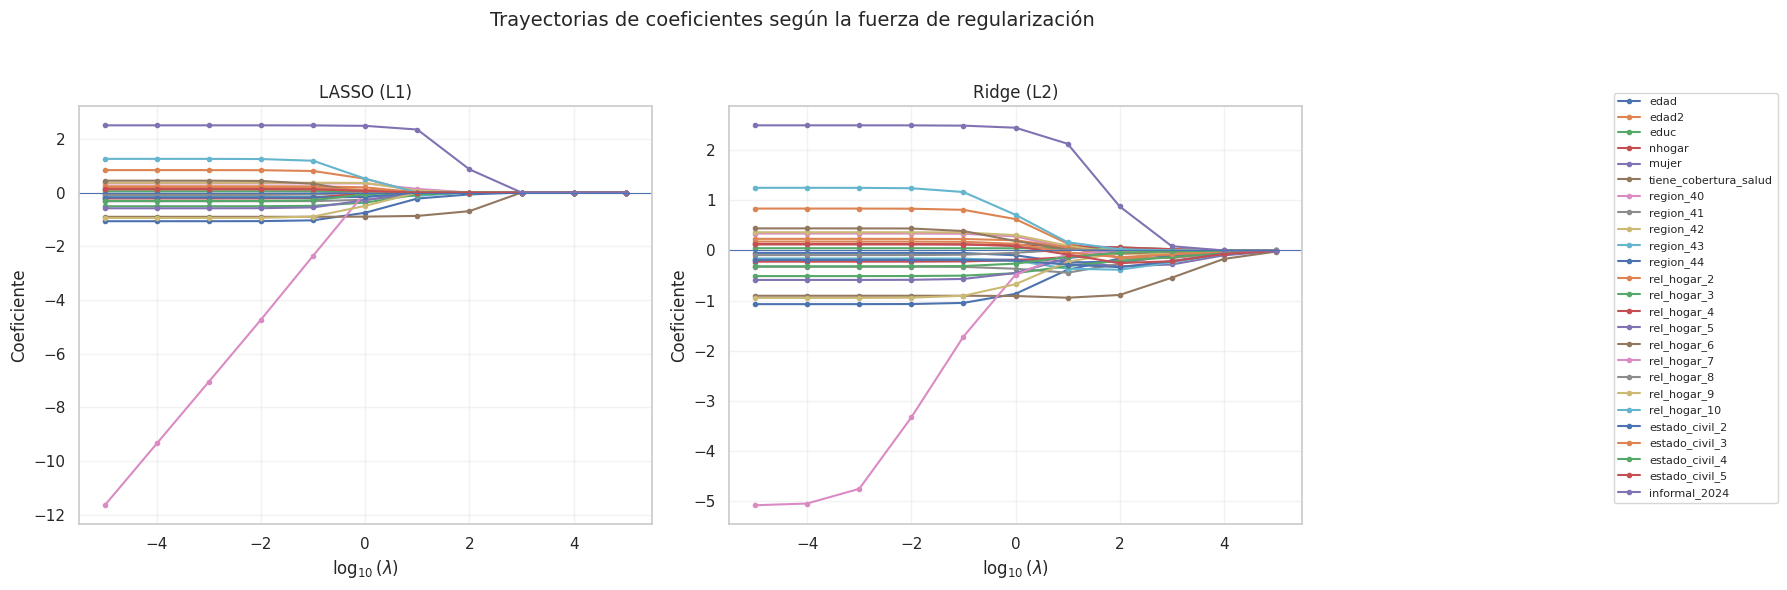


Figura guardada en:
/content/drive/MyDrive/taller_de_programacion/salidas_tp4/figuras/Figura_A1_Trayectorias_LASSO_Ridge.png


In [27]:
# ============================================================
# Celda 15 - A.1 Trayectorias de coeficientes LASSO y Ridge
# ============================================================

from sklearn.linear_model import LogisticRegression
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Grilla exigida por la consigna
exponentes = np.arange(-5, 6)
lambdas = 10.0 ** exponentes
Cs = 1.0 / lambdas

coef_lasso = []
coef_ridge = []

for C in Cs:

    # LASSO - penalización L1
    modelo_lasso = LogisticRegression(
        penalty="l1",
        C=C,
        solver="liblinear",
        max_iter=5000,
        random_state=42
    )

    modelo_lasso.fit(X_tp4_scaled, y_tp4)
    coef_lasso.append(modelo_lasso.coef_[0])

    # RIDGE - penalización L2
    modelo_ridge = LogisticRegression(
        penalty="l2",
        C=C,
        solver="liblinear",
        max_iter=5000,
        random_state=42
    )

    modelo_ridge.fit(X_tp4_scaled, y_tp4)
    coef_ridge.append(modelo_ridge.coef_[0])

coef_lasso = np.array(coef_lasso)
coef_ridge = np.array(coef_ridge)

# ------------------------------------------------------------
# Tabla auxiliar
# ------------------------------------------------------------

tabla_lambdas = pd.DataFrame({
    "lambda": lambdas,
    "C": Cs
})

display(tabla_lambdas)

print("Dimensión coeficientes LASSO:", coef_lasso.shape)
print("Dimensión coeficientes Ridge:", coef_ridge.shape)

# ------------------------------------------------------------
# Figura: dos paneles solicitados
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# LASSO
for j, variable in enumerate(X_tp4_scaled.columns):
    axes[0].plot(
        exponentes,
        coef_lasso[:, j],
        marker="o",
        markersize=3,
        label=variable
    )

axes[0].axhline(0, linewidth=0.8)
axes[0].set_title("LASSO (L1)")
axes[0].set_xlabel(r"$\log_{10}(\lambda)$")
axes[0].set_ylabel("Coeficiente")
axes[0].grid(alpha=0.25)

# Ridge
for j, variable in enumerate(X_tp4_scaled.columns):
    axes[1].plot(
        exponentes,
        coef_ridge[:, j],
        marker="o",
        markersize=3,
        label=variable
    )

axes[1].axhline(0, linewidth=0.8)
axes[1].set_title("Ridge (L2)")
axes[1].set_xlabel(r"$\log_{10}(\lambda)$")
axes[1].set_ylabel("Coeficiente")
axes[1].grid(alpha=0.25)

# Una sola leyenda para ambos paneles
handles, labels = axes[1].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="center left",
    bbox_to_anchor=(1.01, 0.5),
    fontsize=8
)

fig.suptitle(
    "Trayectorias de coeficientes según la fuerza de regularización",
    fontsize=14
)

plt.tight_layout(rect=[0, 0, 0.83, 0.95])

# Guardar figura
ruta_figura_a1 = ruta_figuras + "Figura_A1_Trayectorias_LASSO_Ridge.png"
plt.savefig(
    ruta_figura_a1,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nFigura guardada en:")
print(ruta_figura_a1)

In [28]:
# ============================================================
# Celda 16 - Diagnóstico de regularización A.1
# ============================================================

tol = 1e-8

resumen_regularizacion = pd.DataFrame({
    "lambda": lambdas,
    "C": Cs,
    "LASSO_coef_cero": (np.abs(coef_lasso) < tol).sum(axis=1),
    "LASSO_coef_no_cero": (np.abs(coef_lasso) >= tol).sum(axis=1),
    "Ridge_coef_cero": (np.abs(coef_ridge) < tol).sum(axis=1),
    "Ridge_coef_no_cero": (np.abs(coef_ridge) >= tol).sum(axis=1),
    "LASSO_max_abs": np.abs(coef_lasso).max(axis=1),
    "Ridge_max_abs": np.abs(coef_ridge).max(axis=1)
})

display(resumen_regularizacion)

# Variables llevadas exactamente a cero por LASSO para cada lambda
for i, lam in enumerate(lambdas):
    variables_cero = list(
        X_tp4_scaled.columns[np.abs(coef_lasso[i]) < tol]
    )
    print(f"\nlambda = {lam:.0e}")
    print("Variables en cero:", variables_cero)

,lambda,C,LASSO_coef_cero,LASSO_coef_no_cero,Ridge_coef_cero,Ridge_coef_no_cero,LASSO_max_abs,Ridge_max_abs
0,0.0000,"100,000.0000",0,25,0,25,11.6465,5.0933
1,0.0001,"10,000.0000",0,25,0,25,9.3438,5.0586
2,0.0010,"1,000.0000",0,25,0,25,7.0405,4.7647
3,0.0100,100.0000,0,25,0,25,4.7305,3.3370
4,0.1000,10.0000,0,25,0,25,2.4989,2.4958
5,1.0000,1.0000,4,21,0,25,2.4831,2.4542
6,10.0000,0.1000,15,10,0,25,2.3449,2.1339
7,100.0000,0.0100,22,3,0,25,0.8624,0.8892
8,"1,000.0000",0.0010,25,0,0,25,0.0000,0.5448
9,"10,000.0000",0.0001,25,0,0,25,0.0000,0.1684



lambda = 1e-05
Variables en cero: []

lambda = 1e-04
Variables en cero: []

lambda = 1e-03
Variables en cero: []

lambda = 1e-02
Variables en cero: []

lambda = 1e-01
Variables en cero: []

lambda = 1e+00
Variables en cero: ['region_44', 'rel_hogar_6', 'rel_hogar_7', 'rel_hogar_8']

lambda = 1e+01
Variables en cero: ['edad2', 'educ', 'region_44', 'rel_hogar_2', 'rel_hogar_4', 'rel_hogar_5', 'rel_hogar_6', 'rel_hogar_7', 'rel_hogar_8', 'rel_hogar_9', 'rel_hogar_10', 'estado_civil_2', 'estado_civil_3', 'estado_civil_4', 'estado_civil_5']

lambda = 1e+02
Variables en cero: ['edad2', 'educ', 'nhogar', 'mujer', 'region_40', 'region_41', 'region_42', 'region_43', 'region_44', 'rel_hogar_2', 'rel_hogar_3', 'rel_hogar_4', 'rel_hogar_5', 'rel_hogar_6', 'rel_hogar_7', 'rel_hogar_8', 'rel_hogar_9', 'rel_hogar_10', 'estado_civil_2', 'estado_civil_3', 'estado_civil_4', 'estado_civil_5']

lambda = 1e+03
Variables en cero: ['edad', 'edad2', 'educ', 'nhogar', 'mujer', 'tiene_cobertura_salud', 'region

### A.2. Selección de $\lambda$ mediante validación cruzada

Para seleccionar la intensidad de regularización se utiliza validación cruzada de 5 folds. Para cada valor de $\lambda$ se estima el modelo en cuatro folds y se evalúa el error de clasificación en el fold restante.

La estandarización de las variables numéricas se realiza dentro de cada partición de entrenamiento, evitando utilizar información del fold de validación. Las variables dummy permanecen en escala 0-1.

Se selecciona como $\lambda_{CV}$ aquel que presenta el menor error promedio de clasificación.

In [29]:
# ============================================================
# Celda 17 - A.2 Cross-Validation 5-fold para LASSO y Ridge
# ============================================================

from sklearn.model_selection import StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import pandas as pd
import numpy as np

X_cv = ocupados_X_2025_MM.copy()
y_cv = y_2025_MM.copy()

variables_numericas = ["edad", "edad2", "educ", "nhogar"]

variables_dummies = [
    c for c in X_cv.columns
    if c not in variables_numericas
]

# Estandariza únicamente numéricas y deja dummies sin transformar
preprocesador = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), variables_numericas),
        ("dummy", "passthrough", variables_dummies)
    ]
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

resultados_cv = []

for penalizacion in ["l1", "l2"]:

    for lam, C in zip(lambdas, Cs):

        errores_fold = []

        for fold, (idx_train, idx_val) in enumerate(
            cv.split(X_cv, y_cv),
            start=1
        ):

            X_train = X_cv.iloc[idx_train]
            X_val = X_cv.iloc[idx_val]

            y_train = y_cv.iloc[idx_train]
            y_val = y_cv.iloc[idx_val]

            modelo = Pipeline([
                ("preprocesamiento", preprocesador),
                ("modelo", LogisticRegression(
                    penalty=penalizacion,
                    C=C,
                    solver="liblinear",
                    max_iter=5000,
                    random_state=42
                ))
            ])

            modelo.fit(X_train, y_train)

            pred = modelo.predict(X_val)

            error = 1 - accuracy_score(y_val, pred)

            errores_fold.append(error)

            resultados_cv.append({
                "metodo": "LASSO" if penalizacion == "l1" else "Ridge",
                "lambda": lam,
                "log10_lambda": np.log10(lam),
                "fold": fold,
                "error_clasificacion": error
            })

resultados_cv = pd.DataFrame(resultados_cv)

resumen_cv = (
    resultados_cv
    .groupby(["metodo", "lambda"], as_index=False)
    .agg(
        error_promedio=("error_clasificacion", "mean"),
        error_std=("error_clasificacion", "std")
    )
)

display(resumen_cv)

,metodo,lambda,error_promedio,error_std
0,LASSO,0.0000,0.0632,0.0018
1,LASSO,0.0001,0.0632,0.0018
2,LASSO,0.0010,0.0632,0.0018
3,LASSO,0.0100,0.0632,0.0018
4,LASSO,0.1000,0.0632,0.0018
5,LASSO,1.0000,0.0633,0.0020
6,LASSO,10.0000,0.0627,0.0013
7,LASSO,100.0000,0.0619,0.0000
8,LASSO,"1,000.0000",0.0619,0.0000
9,LASSO,"10,000.0000",0.0619,0.0000


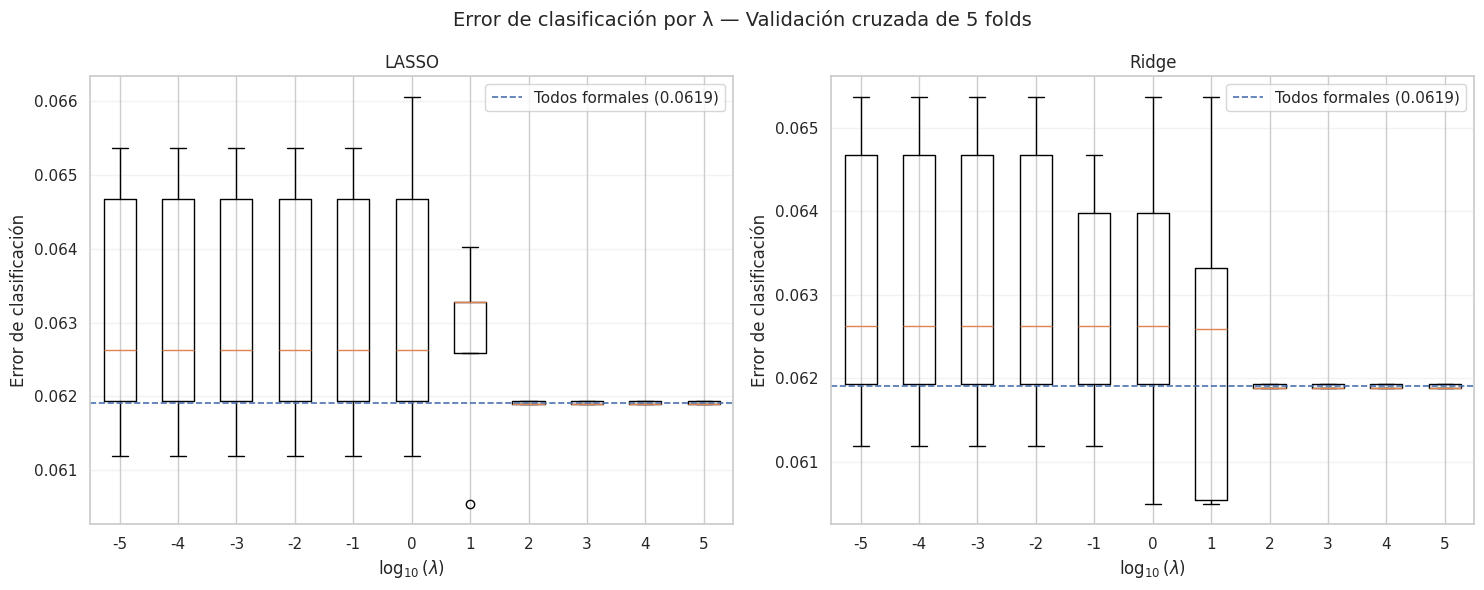

Figura guardada en:
/content/drive/MyDrive/taller_de_programacion/salidas_tp4/figuras/Figura_A2_CV_LASSO_Ridge.png


In [30]:
# ============================================================
# Celda 18 - A.2 Boxplots de error de clasificación
# ============================================================

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, metodo in zip(axes, ["LASSO", "Ridge"]):

    datos = resultados_cv[resultados_cv["metodo"] == metodo]

    datos_box = [
        datos.loc[
            datos["lambda"] == lam,
            "error_clasificacion"
        ].values
        for lam in lambdas
    ]

    ax.boxplot(
        datos_box,
        positions=exponentes,
        widths=0.55
    )

    # Error del clasificador trivial: todos formales
    error_naive = y_2025_MM.mean()

    ax.axhline(
        error_naive,
        linestyle="--",
        linewidth=1.2,
        label=f"Todos formales ({error_naive:.4f})"
    )

    ax.set_title(metodo)
    ax.set_xlabel(r"$\log_{10}(\lambda)$")
    ax.set_ylabel("Error de clasificación")
    ax.grid(axis="y", alpha=0.25)
    ax.legend()

fig.suptitle(
    "Error de clasificación por λ — Validación cruzada de 5 folds",
    fontsize=14
)

plt.tight_layout()

ruta_figura_a2 = (
    ruta_figuras +
    "Figura_A2_CV_LASSO_Ridge.png"
)

plt.savefig(
    ruta_figura_a2,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figura guardada en:")
print(ruta_figura_a2)

In [31]:
# ============================================================
# Celda 19 - Selección preliminar de lambda_CV
# ============================================================

mejores_lambda = (
    resumen_cv
    .loc[
        resumen_cv.groupby("metodo")["error_promedio"].idxmin()
    ]
    .copy()
)

print("Lambda con menor error promedio:")
display(mejores_lambda)

print(
    "\nError clasificador trivial (todos formales):",
    round(y_2025_MM.mean(), 4)
)

Lambda con menor error promedio:


,metodo,lambda,error_promedio,error_std
7,LASSO,100.0000,0.0619,0.0000
18,Ridge,100.0000,0.0619,0.0000



Error clasificador trivial (todos formales): 0.0619


### Diagnóstico del $\lambda_{CV}$ seleccionado

El menor error promedio de clasificación se obtiene con $\lambda=100$ tanto para LASSO como para Ridge. Sin embargo, dicho error coincide con el de un clasificador que asigna todas las observaciones a la categoría mayoritaria (“formal”).

Dado el desbalance de la variable objetivo, se verifica a continuación si los modelos seleccionados mediante este criterio conservan capacidad para identificar trabajadores informales.

In [32]:
# ============================================================
# Celda 20 - Diagnóstico de lambda_CV = 100
# ============================================================

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

lambda_cv_lasso = 100.0
lambda_cv_ridge = 100.0

resultados_diagnostico = []

for metodo, penalty, lam in [
    ("LASSO", "l1", lambda_cv_lasso),
    ("Ridge", "l2", lambda_cv_ridge)
]:

    C = 1.0 / lam

    modelo = Pipeline([
        ("preprocesamiento", preprocesador),
        ("modelo", LogisticRegression(
            penalty=penalty,
            C=C,
            solver="liblinear",
            max_iter=5000,
            random_state=42
        ))
    ])

    # Diagnóstico sobre toda la muestra:
    # NO es todavía la evaluación final fuera de muestra.
    modelo.fit(X_cv, y_cv)

    pred = modelo.predict(X_cv)
    prob = modelo.predict_proba(X_cv)[:, 1]

    tn, fp, fn, tp = confusion_matrix(y_cv, pred).ravel()

    resultados_diagnostico.append({
        "metodo": metodo,
        "lambda_CV": lam,
        "predichos_informales": int(pred.sum()),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "accuracy": accuracy_score(y_cv, pred),
        "precision": precision_score(y_cv, pred, zero_division=0),
        "recall": recall_score(y_cv, pred, zero_division=0),
        "F1": f1_score(y_cv, pred, zero_division=0),
        "AUC": roc_auc_score(y_cv, prob)
    })

diagnostico_lambda = pd.DataFrame(resultados_diagnostico)

display(diagnostico_lambda.round(4))

,metodo,lambda_CV,predichos_informales,TN,FP,FN,TP,accuracy,precision,recall,F1,AUC
0,LASSO,100.0000,0,6743,0,445,0,0.9381,0.0000,0.0000,0.0000,0.7944
1,Ridge,100.0000,0,6743,0,445,0,0.9381,0.0000,0.0000,0.0000,0.7702


### A.3. Estimación de los modelos seleccionados

Con los valores de $\lambda_{CV}$ obtenidos mediante validación cruzada se estiman los modelos LASSO y Ridge. Como referencia, se estima además una regresión logística sin penalización utilizando el mismo conjunto de predictores.

La comparación de coeficientes permite observar el efecto de la regularización: LASSO puede llevar coeficientes exactamente a cero, mientras que Ridge los contrae hacia cero sin eliminarlos.

In [33]:
# ============================================================
# Celda 21 - A.3 Logit, LASSO y Ridge
# Tabla conjunta de coeficientes
# ============================================================

# Mantener el mismo orden final de variables
variables_finales = variables_numericas + variables_dummies

# Preprocesamiento definitivo:
# StandardScaler solo para numéricas; dummies permanecen 0/1
preprocesador_final = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), variables_numericas),
        ("dummy", "passthrough", variables_dummies)
    ]
)

modelos_a3 = {
    "Logit_sin_penalizacion": LogisticRegression(
        penalty=None,
        solver="lbfgs",
        max_iter=10000,
        random_state=42
    ),

    "LASSO": LogisticRegression(
        penalty="l1",
        C=1.0 / lambda_cv_lasso,
        solver="liblinear",
        max_iter=5000,
        random_state=42
    ),

    "Ridge": LogisticRegression(
        penalty="l2",
        C=1.0 / lambda_cv_ridge,
        solver="liblinear",
        max_iter=5000,
        random_state=42
    )
}

coeficientes_a3 = pd.DataFrame(
    index=variables_finales
)

interceptos_a3 = {}

modelos_estimados_a3 = {}

for nombre, estimador in modelos_a3.items():

    pipeline = Pipeline([
        ("preprocesamiento", preprocesador_final),
        ("modelo", estimador)
    ])

    pipeline.fit(X_cv, y_cv)

    modelos_estimados_a3[nombre] = pipeline

    coef = pipeline.named_steps["modelo"].coef_[0]
    intercepto = pipeline.named_steps["modelo"].intercept_[0]

    coeficientes_a3[nombre] = coef
    interceptos_a3[nombre] = intercepto

# Agregar intercepto
tabla_coeficientes_a3 = pd.concat([
    pd.DataFrame(
        {
            nombre: [interceptos_a3[nombre]]
            for nombre in modelos_a3.keys()
        },
        index=["Intercepto"]
    ),
    coeficientes_a3
])

# Redondeo solo para presentación
display(tabla_coeficientes_a3.round(4))

print("\nCoeficientes exactamente iguales a cero en LASSO:")
variables_cero_lasso = tabla_coeficientes_a3.index[
    np.isclose(
        tabla_coeficientes_a3["LASSO"],
        0.0,
        atol=1e-8
    )
].tolist()

print(variables_cero_lasso)

print(
    "\nCantidad de coeficientes en cero LASSO:",
    len(variables_cero_lasso)
)

,Logit_sin_penalizacion,LASSO,Ridge
Intercepto,-2.5685,-2.1421,-1.4031
edad,-1.1652,-0.0712,-0.1603
edad2,0.9293,0.0000,-0.0630
educ,0.0449,0.0000,0.0599
nhogar,0.1233,0.0000,0.0631
mujer,-0.1809,0.0000,-0.3180
tiene_cobertura_salud,-0.9067,-0.6945,-0.8892
region_40,0.3317,0.0000,-0.1392
region_41,-0.3558,0.0000,-0.2628
region_42,0.3541,0.0000,-0.0602



Coeficientes exactamente iguales a cero en LASSO:
['edad2', 'educ', 'nhogar', 'mujer', 'region_40', 'region_41', 'region_42', 'region_43', 'region_44', 'rel_hogar_2', 'rel_hogar_3', 'rel_hogar_4', 'rel_hogar_5', 'rel_hogar_6', 'rel_hogar_7', 'rel_hogar_8', 'rel_hogar_9', 'rel_hogar_10', 'estado_civil_2', 'estado_civil_3', 'estado_civil_4', 'estado_civil_5']

Cantidad de coeficientes en cero LASSO: 22


**Interpretación.** La regularización modifica de manera importante la magnitud de los coeficientes. Ridge contrae todos los parámetros hacia cero, pero mantiene todos los predictores en el modelo. LASSO, con el valor de $\lambda$ seleccionado mediante validación cruzada, produce una solución mucho más parsimoniosa: 22 de los 25 coeficientes son llevados exactamente a cero.

Los tres predictores que permanecen activos bajo LASSO son `edad`, `tiene_cobertura_salud` e `informal_2024`. Entre ellos, el rezago de informalidad presenta un coeficiente positivo, consistente con persistencia en la condición de informalidad entre 2024 y 2025. La cobertura de salud presenta una asociación negativa con la probabilidad de informalidad, mientras que el coeficiente de edad es negativo y de menor magnitud.

Estos coeficientes deben interpretarse como asociaciones predictivas y no como efectos causales.

In [34]:
# ============================================================
# Celda 22 - Exportar tabla A.3
# ============================================================

ruta_tabla_a3 = ruta_tablas + "Tabla_A3_Coeficientes_Logit_LASSO_Ridge.xlsx"

tabla_coeficientes_a3.round(6).to_excel(
    ruta_tabla_a3,
    sheet_name="Coeficientes"
)

print("Tabla A.3 guardada en:")
print(ruta_tabla_a3)

Tabla A.3 guardada en:
/content/drive/MyDrive/taller_de_programacion/salidas_tp4/tablas/Tabla_A3_Coeficientes_Logit_LASSO_Ridge.xlsx


## B. Árbol de Clasificación CART

Se estima un árbol de clasificación sobre `ocupados_X_2025_MM` para predecir `y_2025_MM`.

La complejidad del árbol se controla mediante poda por costo-complejidad. Se obtiene una secuencia de valores candidatos de `ccp_alpha` y posteriormente se selecciona el valor óptimo mediante validación cruzada de 5 folds.

In [35]:
# ============================================================
# Celda 23 - B.1 Secuencia de ccp_alpha para CART
# ============================================================

from sklearn.tree import DecisionTreeClassifier
import numpy as np
import pandas as pd

X_cart = ocupados_X_2025_MM.copy()
y_cart = y_2025_MM.copy()

# Árbol inicial sin poda
arbol_inicial = DecisionTreeClassifier(
    random_state=42,
    class_weight=None
)

arbol_inicial.fit(X_cart, y_cart)

# Camino de poda costo-complejidad
path = arbol_inicial.cost_complexity_pruning_path(
    X_cart,
    y_cart
)

ccp_alphas = path.ccp_alphas
impurezas = path.impurities

tabla_ccp = pd.DataFrame({
    "ccp_alpha": ccp_alphas,
    "impureza_total": impurezas
})

print("Cantidad de valores ccp_alpha:", len(ccp_alphas))
print("ccp_alpha mínimo:", ccp_alphas.min())
print("ccp_alpha máximo:", ccp_alphas.max())

display(tabla_ccp.head(10))
display(tabla_ccp.tail(10))

Cantidad de valores ccp_alpha: 207
ccp_alpha mínimo: 0.0
ccp_alpha máximo: 0.014656778732505912


,ccp_alpha,impureza_total
0,0.0000,0.0022
1,0.0000,0.0022
2,0.0000,0.0024
3,0.0000,0.0024
4,0.0000,0.0025
5,0.0000,0.0027
6,0.0000,0.0027
7,0.0000,0.0028
8,0.0000,0.0029
9,0.0000,0.0030


,ccp_alpha,impureza_total
197,0.0003,0.0955
198,0.0004,0.0959
199,0.0004,0.0966
200,0.0004,0.0974
201,0.0004,0.0978
202,0.0004,0.0982
203,0.0009,0.0991
204,0.0011,0.1002
205,0.0013,0.1015
206,0.0147,0.1162


### B.2. Selección de `ccp_alpha` mediante validación cruzada

A partir de la secuencia de parámetros de costo-complejidad obtenida del árbol inicial, se selecciona una grilla representativa de valores de `ccp_alpha`.

Para cada valor se realiza validación cruzada estratificada de 5 folds y se calcula el error de clasificación. El parámetro seleccionado, `ccp_alpha_CV`, corresponde al valor que minimiza el error promedio de validación.

Dado el desbalance de la variable objetivo, el error de clasificación se utiliza para respetar el criterio de selección solicitado, mientras que posteriormente se analizarán métricas adicionales de desempeño.

In [36]:
# ============================================================
# Celda 24 - B.2 Cross-Validation 5-fold para ccp_alpha
# ============================================================

from sklearn.model_selection import StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. Construcción de una grilla representativa
# ------------------------------------------------------------

# Eliminar duplicados y ordenar
alphas_unicos = np.unique(ccp_alphas)

# Seleccionar hasta 50 posiciones distribuidas a lo largo
# de toda la secuencia de poda
n_grid = min(50, len(alphas_unicos))

indices_grid = np.linspace(
    0,
    len(alphas_unicos) - 1,
    n_grid,
    dtype=int
)

ccp_alpha_grid = alphas_unicos[indices_grid]

# Asegurar inclusión del mínimo y máximo
ccp_alpha_grid = np.unique(
    np.concatenate([
        [alphas_unicos.min()],
        ccp_alpha_grid,
        [alphas_unicos.max()]
    ])
)

print("Cantidad de alphas originales:", len(alphas_unicos))
print("Cantidad de alphas evaluados en CV:", len(ccp_alpha_grid))
print("Rango:",
      ccp_alpha_grid.min(),
      "a",
      ccp_alpha_grid.max())

# ------------------------------------------------------------
# 2. Validación cruzada estratificada de 5 folds
# ------------------------------------------------------------

cv_cart = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

resultados_cart_cv = []

for alpha in ccp_alpha_grid:

    for fold, (idx_train, idx_val) in enumerate(
        cv_cart.split(X_cart, y_cart),
        start=1
    ):

        X_train = X_cart.iloc[idx_train]
        X_val = X_cart.iloc[idx_val]

        y_train = y_cart.iloc[idx_train]
        y_val = y_cart.iloc[idx_val]

        modelo_cart = DecisionTreeClassifier(
            random_state=42,
            ccp_alpha=alpha,
            class_weight=None
        )

        modelo_cart.fit(X_train, y_train)

        pred = modelo_cart.predict(X_val)

        error = 1 - accuracy_score(y_val, pred)

        resultados_cart_cv.append({
            "ccp_alpha": alpha,
            "fold": fold,
            "error_clasificacion": error
        })

resultados_cart_cv = pd.DataFrame(resultados_cart_cv)

# ------------------------------------------------------------
# 3. Resumen por ccp_alpha
# ------------------------------------------------------------

resumen_cart_cv = (
    resultados_cart_cv
    .groupby("ccp_alpha", as_index=False)
    .agg(
        error_promedio=("error_clasificacion", "mean"),
        error_std=("error_clasificacion", "std")
    )
)

# Selección del alpha con menor error promedio
idx_mejor = resumen_cart_cv["error_promedio"].idxmin()

ccp_alpha_CV = resumen_cart_cv.loc[
    idx_mejor, "ccp_alpha"
]

error_min_cart = resumen_cart_cv.loc[
    idx_mejor, "error_promedio"
]

print("\nccp_alpha_CV seleccionado:", ccp_alpha_CV)
print("Error promedio mínimo:", round(error_min_cart, 6))

print("\nMejores 10 valores según error promedio:")
display(
    resumen_cart_cv
    .sort_values(
        ["error_promedio", "ccp_alpha"],
        ascending=[True, True]
    )
    .head(10)
)

Cantidad de alphas originales: 170
Cantidad de alphas evaluados en CV: 50
Rango: 0.0 a 0.014656778732505912

ccp_alpha_CV seleccionado: 0.014656778732505912
Error promedio mínimo: 0.061909

Mejores 10 valores según error promedio:


,ccp_alpha,error_promedio,error_std
49,0.0147,0.0619,0.0000
47,0.0004,0.0620,0.0038
48,0.0004,0.0620,0.0028
46,0.0003,0.0652,0.0023
44,0.0002,0.0690,0.0029
45,0.0003,0.0690,0.0021
43,0.0002,0.0705,0.0040
42,0.0002,0.0723,0.0060
41,0.0002,0.0736,0.0062
39,0.0002,0.0743,0.0059


### B.1. Selección del parámetro de poda

La validación cruzada de 5 folds selecciona el parámetro `ccp_alpha` que minimiza el error promedio de clasificación. Dado el fuerte desbalance de la variable objetivo, se compara nuevamente el error obtenido con el correspondiente a clasificar todas las observaciones como formales.

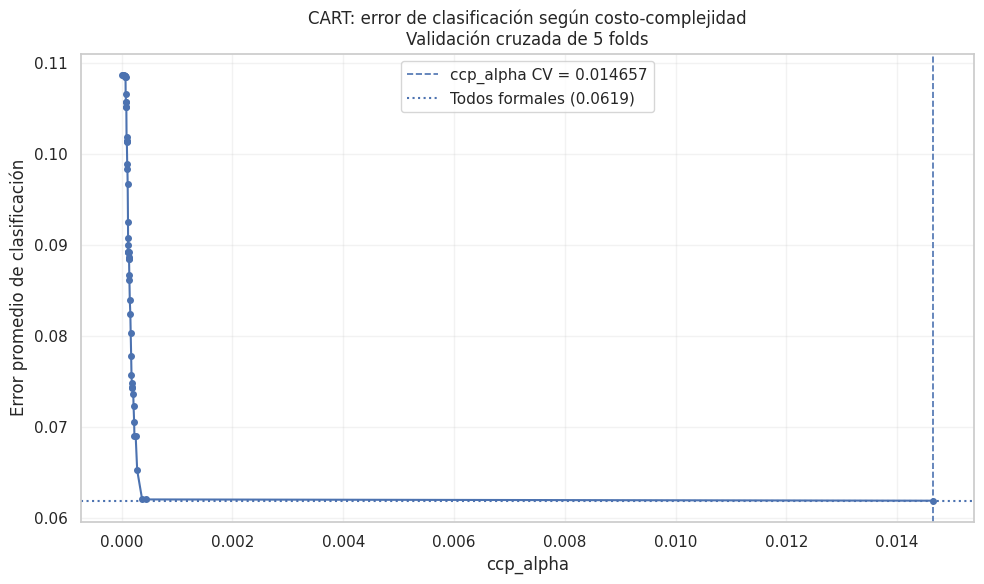

Figura guardada en:
/content/drive/MyDrive/taller_de_programacion/salidas_tp4/figuras/Figura_B1_CV_CCP_Alpha.png


In [37]:
# ============================================================
# Celda 25 - B.1 Error de clasificación vs ccp_alpha
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    resumen_cart_cv["ccp_alpha"],
    resumen_cart_cv["error_promedio"],
    marker="o",
    markersize=4
)

# Alpha seleccionado
plt.axvline(
    ccp_alpha_CV,
    linestyle="--",
    linewidth=1.2,
    label=f"ccp_alpha CV = {ccp_alpha_CV:.6f}"
)

# Clasificador trivial
error_naive = y_cart.mean()

plt.axhline(
    error_naive,
    linestyle=":",
    linewidth=1.5,
    label=f"Todos formales ({error_naive:.4f})"
)

plt.xlabel("ccp_alpha")
plt.ylabel("Error promedio de clasificación")
plt.title(
    "CART: error de clasificación según costo-complejidad\n"
    "Validación cruzada de 5 folds"
)

plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()

ruta_figura_b1 = (
    ruta_figuras +
    "Figura_B1_CV_CCP_Alpha.png"
)

plt.savefig(
    ruta_figura_b1,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figura guardada en:")
print(ruta_figura_b1)

In [38]:
# ============================================================
# Celda 26 - Diagnóstico del CART seleccionado por CV
# ============================================================

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

cart_cv = DecisionTreeClassifier(
    random_state=42,
    ccp_alpha=ccp_alpha_CV,
    class_weight=None
)

cart_cv.fit(X_cart, y_cart)

pred_cart_diag = cart_cv.predict(X_cart)
prob_cart_diag = cart_cv.predict_proba(X_cart)[:, 1]

tn, fp, fn, tp = confusion_matrix(
    y_cart,
    pred_cart_diag
).ravel()

print("ccp_alpha seleccionado:", ccp_alpha_CV)

print("\nEstructura del árbol:")
print("Profundidad:", cart_cv.get_depth())
print("Número de hojas:", cart_cv.get_n_leaves())
print("Número de nodos:", cart_cv.tree_.node_count)

print("\nPredicciones:")
print("Informales observados:", int(y_cart.sum()))
print("Informales predichos:", int(pred_cart_diag.sum()))

print("\nMatriz de confusión:")
print(confusion_matrix(y_cart, pred_cart_diag))

print("\nMétricas diagnósticas:")
print("Accuracy :", round(accuracy_score(y_cart, pred_cart_diag), 4))
print("1-Accuracy:", round(1 - accuracy_score(y_cart, pred_cart_diag), 4))
print("Precision:", round(precision_score(y_cart, pred_cart_diag, zero_division=0), 4))
print("Recall   :", round(recall_score(y_cart, pred_cart_diag, zero_division=0), 4))
print("F1       :", round(f1_score(y_cart, pred_cart_diag, zero_division=0), 4))
print("AUC      :", round(roc_auc_score(y_cart, prob_cart_diag), 4))

ccp_alpha seleccionado: 0.014656778732505912

Estructura del árbol:
Profundidad: 0
Número de hojas: 1
Número de nodos: 1

Predicciones:
Informales observados: 445
Informales predichos: 0

Matriz de confusión:
[[6743    0]
 [ 445    0]]

Métricas diagnósticas:
Accuracy : 0.9381
1-Accuracy: 0.0619
Precision: 0.0
Recall   : 0.0
F1       : 0.0
AUC      : 0.5


### B.2. Árbol podado seleccionado por validación cruzada

El criterio de mínimo error de clasificación selecciona `ccp_alpha = 0.0146568`. Con este nivel de poda, el árbol queda reducido a un único nodo terminal y clasifica todas las observaciones como formales.

Este resultado refleja el fuerte desbalance de la variable objetivo: dado que solo el 6,19% de las observaciones corresponde a trabajadores informales, un clasificador que siempre predice la clase mayoritaria alcanza un error de clasificación de aproximadamente 6,19%.

Se presenta a continuación el árbol seleccionado estrictamente mediante el criterio solicitado y la importancia resultante de sus predictores.

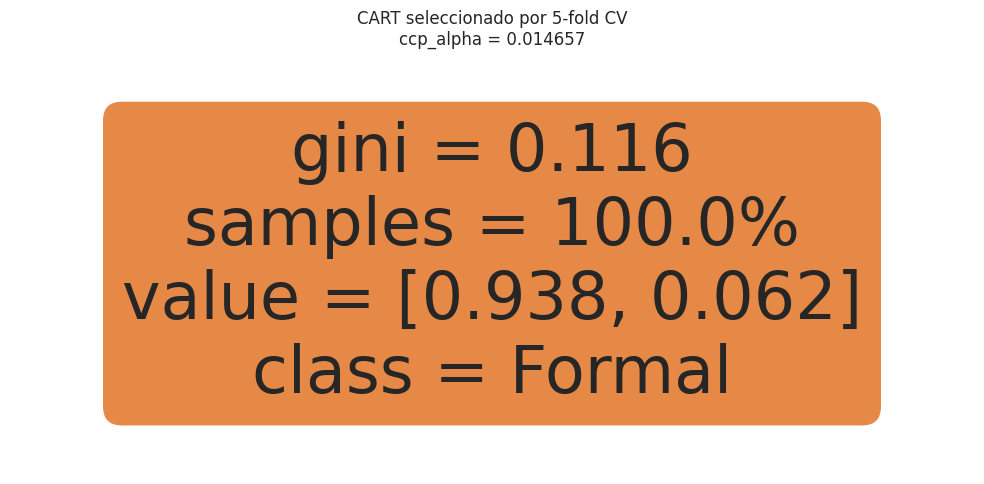

Figura guardada en:
/content/drive/MyDrive/taller_de_programacion/salidas_tp4/figuras/Figura_B2_CART_Seleccionado_CV.png


In [39]:
# ============================================================
# Celda 27 - B.2 Árbol CART seleccionado por CV
# ============================================================

from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plot_tree(
    cart_cv,
    feature_names=X_cart.columns,
    class_names=["Formal", "Informal"],
    filled=True,
    rounded=True,
    proportion=True,
    precision=3
)

plt.title(
    "CART seleccionado por 5-fold CV\n"
    f"ccp_alpha = {ccp_alpha_CV:.6f}"
)

plt.tight_layout()

ruta_figura_b2_arbol = (
    ruta_figuras +
    "Figura_B2_CART_Seleccionado_CV.png"
)

plt.savefig(
    ruta_figura_b2_arbol,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figura guardada en:")
print(ruta_figura_b2_arbol)

In [40]:
# ============================================================
# Celda 28 - B.2 Importancia de predictores CART seleccionado
# ============================================================

importancias_cart = pd.DataFrame({
    "variable": X_cart.columns,
    "importancia_CART": cart_cv.feature_importances_
}).sort_values(
    "importancia_CART",
    ascending=False
).reset_index(drop=True)

display(importancias_cart)

print(
    "Número de variables con importancia > 0:",
    (importancias_cart["importancia_CART"] > 0).sum()
)

,variable,importancia_CART
0,edad,0.0000
1,edad2,0.0000
2,educ,0.0000
3,nhogar,0.0000
4,mujer,0.0000
5,tiene_cobertura_salud,0.0000
6,region_40,0.0000
7,region_41,0.0000
8,region_42,0.0000
9,region_43,0.0000


Número de variables con importancia > 0: 0


In [41]:
# ============================================================
# Celda 29 - Análisis complementario:
# mejor CART no degenerado dentro de la grilla CV
# ============================================================

diagnostico_alphas = []

for alpha in ccp_alpha_grid:

    arbol_tmp = DecisionTreeClassifier(
        random_state=42,
        ccp_alpha=alpha,
        class_weight=None
    )

    arbol_tmp.fit(X_cart, y_cart)

    diagnostico_alphas.append({
        "ccp_alpha": alpha,
        "profundidad": arbol_tmp.get_depth(),
        "hojas": arbol_tmp.get_n_leaves(),
        "nodos": arbol_tmp.tree_.node_count
    })

diagnostico_alphas = pd.DataFrame(diagnostico_alphas)

# Combinar estructura con resultados CV
comparacion_alpha = resumen_cart_cv.merge(
    diagnostico_alphas,
    on="ccp_alpha",
    how="left"
)

# Solo árboles que realmente hagan al menos una partición
candidatos_no_degenerados = comparacion_alpha[
    comparacion_alpha["profundidad"] > 0
].copy()

mejor_no_degenerado = (
    candidatos_no_degenerados
    .sort_values(
        ["error_promedio", "ccp_alpha"],
        ascending=[True, False]
    )
    .head(10)
)

print("Mejores árboles NO degenerados:")
display(mejor_no_degenerado)

Mejores árboles NO degenerados:


,ccp_alpha,error_promedio,error_std,profundidad,hojas,nodos
48,0.0004,0.0620,0.0028,3,5,9
47,0.0004,0.0620,0.0038,5,9,17
46,0.0003,0.0652,0.0023,7,15,29
44,0.0002,0.0690,0.0029,11,35,69
45,0.0003,0.0690,0.0021,10,29,57
43,0.0002,0.0705,0.0040,12,48,95
42,0.0002,0.0723,0.0060,12,58,115
41,0.0002,0.0736,0.0062,12,63,125
39,0.0002,0.0743,0.0059,15,89,177
40,0.0002,0.0744,0.0061,12,77,153


In [42]:
# ============================================================
# Celda 30 - Mejor CART no degenerado
# Análisis complementario de sensibilidad
# ============================================================

fila_mejor_no_deg = (
    candidatos_no_degenerados
    .sort_values(
        ["error_promedio", "ccp_alpha"],
        ascending=[True, False]
    )
    .iloc[0]
)

ccp_alpha_no_deg = float(
    fila_mejor_no_deg["ccp_alpha"]
)

cart_no_deg = DecisionTreeClassifier(
    random_state=42,
    ccp_alpha=ccp_alpha_no_deg,
    class_weight=None
)

cart_no_deg.fit(X_cart, y_cart)

print("ccp_alpha exacto:", ccp_alpha_no_deg)
print("Error CV promedio:",
      fila_mejor_no_deg["error_promedio"])
print("Profundidad:", cart_no_deg.get_depth())
print("Hojas:", cart_no_deg.get_n_leaves())
print("Nodos:", cart_no_deg.tree_.node_count)

ccp_alpha exacto: 0.00044067791644551366
Error CV promedio: 0.06204801960505342
Profundidad: 3
Hojas: 5
Nodos: 9


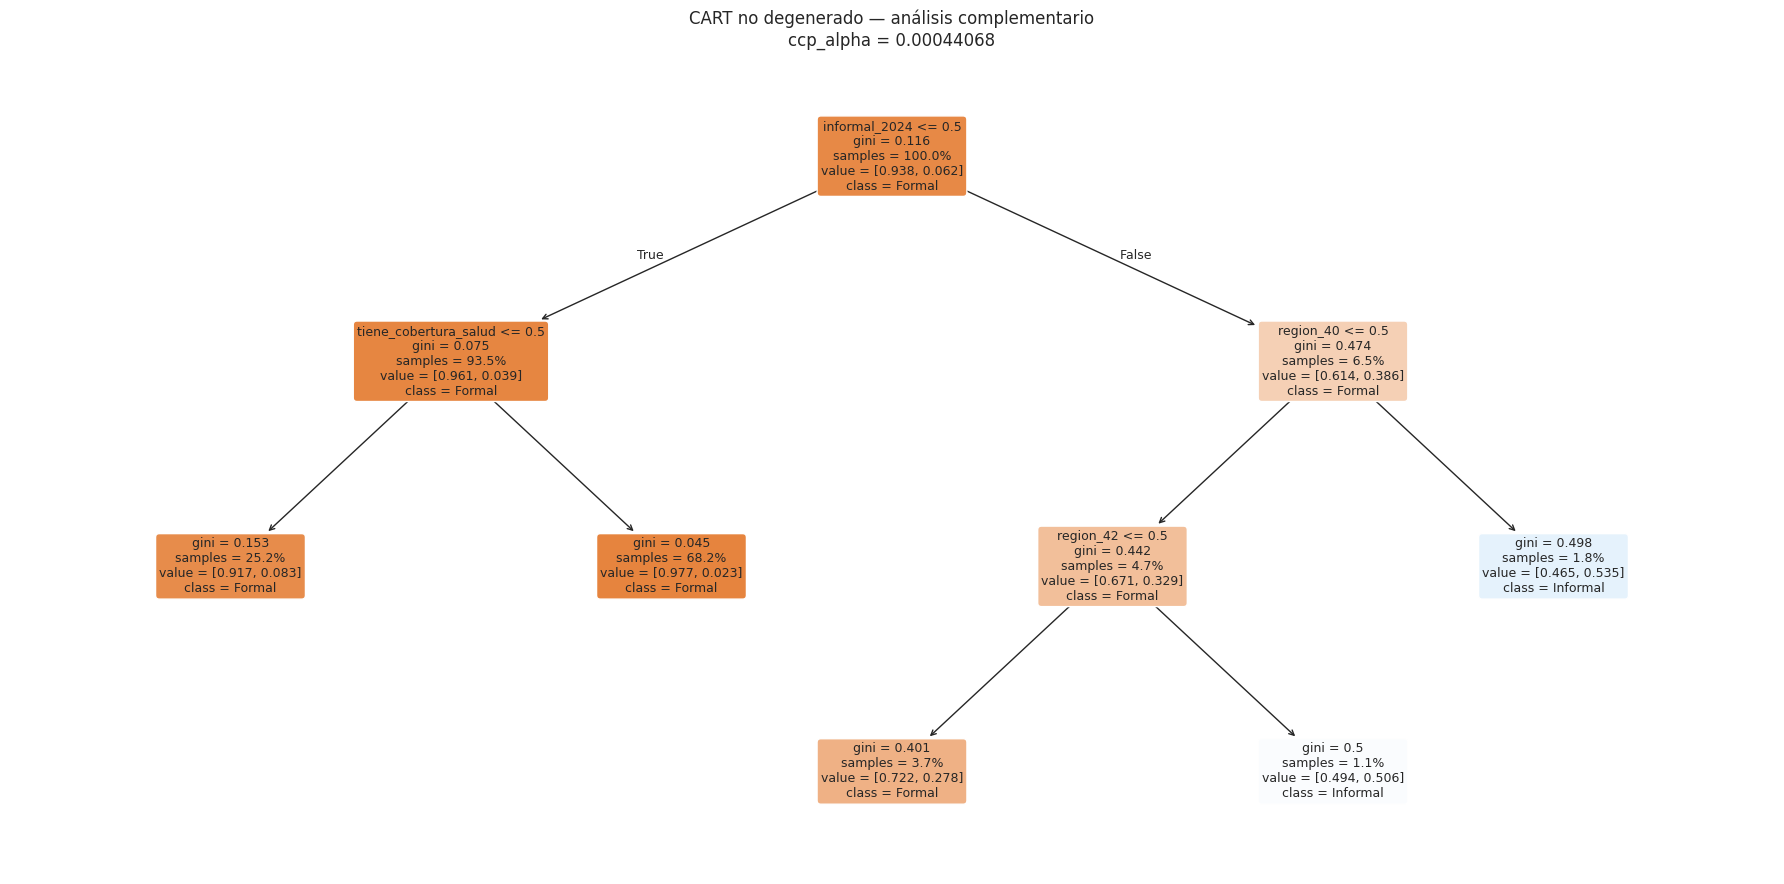

In [43]:
# ============================================================
# Celda 31 - Visualización CART no degenerado
# ============================================================

from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 9))

plot_tree(
    cart_no_deg,
    feature_names=X_cart.columns,
    class_names=["Formal", "Informal"],
    filled=True,
    rounded=True,
    proportion=True,
    precision=3,
    fontsize=9
)

plt.title(
    "CART no degenerado — análisis complementario\n"
    f"ccp_alpha = {ccp_alpha_no_deg:.8f}"
)

plt.tight_layout()

ruta_figura_b2_sens = (
    ruta_figuras +
    "Figura_B2_CART_Sensibilidad_No_Degenerado.png"
)

plt.savefig(
    ruta_figura_b2_sens,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [44]:
# ============================================================
# Celda 32 - Importancia CART vs selección LASSO
# ============================================================

importancias_no_deg = pd.DataFrame({
    "variable": X_cart.columns,
    "importancia_CART_sensibilidad":
        cart_no_deg.feature_importances_
}).sort_values(
    "importancia_CART_sensibilidad",
    ascending=False
).reset_index(drop=True)

# Variables que LASSO dejó en cero
lasso_cero = set([
    v for v in variables_cero_lasso
    if v != "Intercepto"
])

importancias_no_deg["LASSO_coef_cero"] = (
    importancias_no_deg["variable"]
    .isin(lasso_cero)
)

display(importancias_no_deg)

print("\nVariables utilizadas por CART:")
print(
    importancias_no_deg.loc[
        importancias_no_deg[
            "importancia_CART_sensibilidad"
        ] > 0,
        ["variable",
         "importancia_CART_sensibilidad",
         "LASSO_coef_cero"]
    ]
)

print(
    "\nVariables con importancia cero en CART:",
    (
        importancias_no_deg[
            "importancia_CART_sensibilidad"
        ] == 0
    ).sum()
)

,variable,importancia_CART_sensibilidad,LASSO_coef_cero
0,informal_2024,0.8161,False
1,tiene_cobertura_salud,0.0744,False
2,region_40,0.0612,True
3,region_42,0.0484,True
4,edad,0.0000,False
5,mujer,0.0000,True
6,nhogar,0.0000,True
7,educ,0.0000,True
8,edad2,0.0000,True
9,region_41,0.0000,True



Variables utilizadas por CART:
                variable  importancia_CART_sensibilidad  LASSO_coef_cero
0          informal_2024                         0.8161            False
1  tiene_cobertura_salud                         0.0744            False
2              region_40                         0.0612             True
3              region_42                         0.0484             True

Variables con importancia cero en CART: 21


**Comparación CART–LASSO.** El CART seleccionado estrictamente mediante el mínimo error de clasificación queda completamente podado y asigna importancia cero a todos los predictores. Por ello, como análisis complementario se examina el mejor árbol no degenerado, cuyo error de validación cruzada (0,0620) es prácticamente igual al mínimo obtenido por el árbol completamente podado (0,0619).

En este árbol, `informal_2024` concentra el 81,61% de la importancia predictiva, seguida por `tiene_cobertura_salud` (7,44%), `region_40` (6,12%) y `region_42` (4,84%). Existe, por tanto, una coincidencia relevante con LASSO: ambos métodos preservan `informal_2024` y `tiene_cobertura_salud`. Sin embargo, LASSO conserva además `edad`, que CART no utiliza, mientras que CART utiliza `region_40` y `region_42`, cuyos coeficientes fueron llevados a cero por LASSO.

La diferencia es consistente con la naturaleza de ambos métodos: LASSO selecciona predictores dentro de una especificación logística lineal y aditiva, mientras que CART selecciona variables a partir de reglas de partición y puede representar relaciones no lineales e interacciones.

## C. Comparación entre métodos

### C.1. Desempeño predictivo

Se comparan sobre la misma muestra `ocupados_X_2025_MM` los cuatro métodos estimados: regresión logística sin penalización, LASSO, Ridge y CART seleccionado mediante validación cruzada.

Siguiendo el TP3, se utilizan matrices de confusión con umbral de clasificación $p=0,5$, curvas ROC y las métricas accuracy, precision, recall, F1-score y AUC. Adicionalmente, se reporta $1-\mathrm{accuracy}$, tal como solicita la consigna del TP4.

La utilización de una muestra común permite que las diferencias observadas correspondan a los modelos y no a cambios en la composición de la muestra evaluada.

In [45]:
# ============================================================
# Celda 33 - C.1 Evaluación comparable de los cuatro modelos
# ============================================================

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# ------------------------------------------------------------
# Probabilidades de los cuatro modelos
# ------------------------------------------------------------

prob_logit = modelos_estimados_a3[
    "Logit_sin_penalizacion"
].predict_proba(X_cv)[:, 1]

prob_lasso = modelos_estimados_a3[
    "LASSO"
].predict_proba(X_cv)[:, 1]

prob_ridge = modelos_estimados_a3[
    "Ridge"
].predict_proba(X_cv)[:, 1]

prob_cart = cart_cv.predict_proba(X_cart)[:, 1]

probabilidades_modelos = {
    "Logit sin penalización": prob_logit,
    "LASSO": prob_lasso,
    "Ridge": prob_ridge,
    "CART": prob_cart
}

resultados_c1 = []
matrices_c1 = {}
predicciones_c1 = {}

for nombre, prob in probabilidades_modelos.items():

    # Mismo criterio que TP3: p > 0.5
    pred = (prob > 0.5).astype(int)

    matriz = confusion_matrix(y_2025_MM, pred)

    matrices_c1[nombre] = matriz
    predicciones_c1[nombre] = pred

    acc = accuracy_score(y_2025_MM, pred)

    resultados_c1.append({
        "Modelo": nombre,
        "Accuracy": acc,
        "1-Accuracy": 1 - acc,
        "Precision": precision_score(
            y_2025_MM, pred, zero_division=0
        ),
        "Recall": recall_score(
            y_2025_MM, pred, zero_division=0
        ),
        "F1": f1_score(
            y_2025_MM, pred, zero_division=0
        ),
        "AUC": roc_auc_score(
            y_2025_MM, prob
        ),
        "Informales_predichos": int(pred.sum())
    })

tabla_metricas_c1 = pd.DataFrame(resultados_c1)

display(
    tabla_metricas_c1.round(4)
)

# Guardar
ruta_metricas_c1 = (
    ruta_tablas +
    "Tabla_C1_Metricas_Comparacion_Modelos.xlsx"
)

tabla_metricas_c1.to_excel(
    ruta_metricas_c1,
    index=False
)

print("\nTabla guardada en:")
print(ruta_metricas_c1)

,Modelo,Accuracy,1-Accuracy,Precision,Recall,F1,AUC,Informales_predichos
0,Logit sin penalización,0.9378,0.0622,0.4911,0.1236,0.1975,0.8015,112
1,LASSO,0.9381,0.0619,0.0000,0.0000,0.0000,0.7944,0
2,Ridge,0.9381,0.0619,0.0000,0.0000,0.0000,0.7702,0
3,CART,0.9381,0.0619,0.0000,0.0000,0.0000,0.5000,0



Tabla guardada en:
/content/drive/MyDrive/taller_de_programacion/salidas_tp4/tablas/Tabla_C1_Metricas_Comparacion_Modelos.xlsx


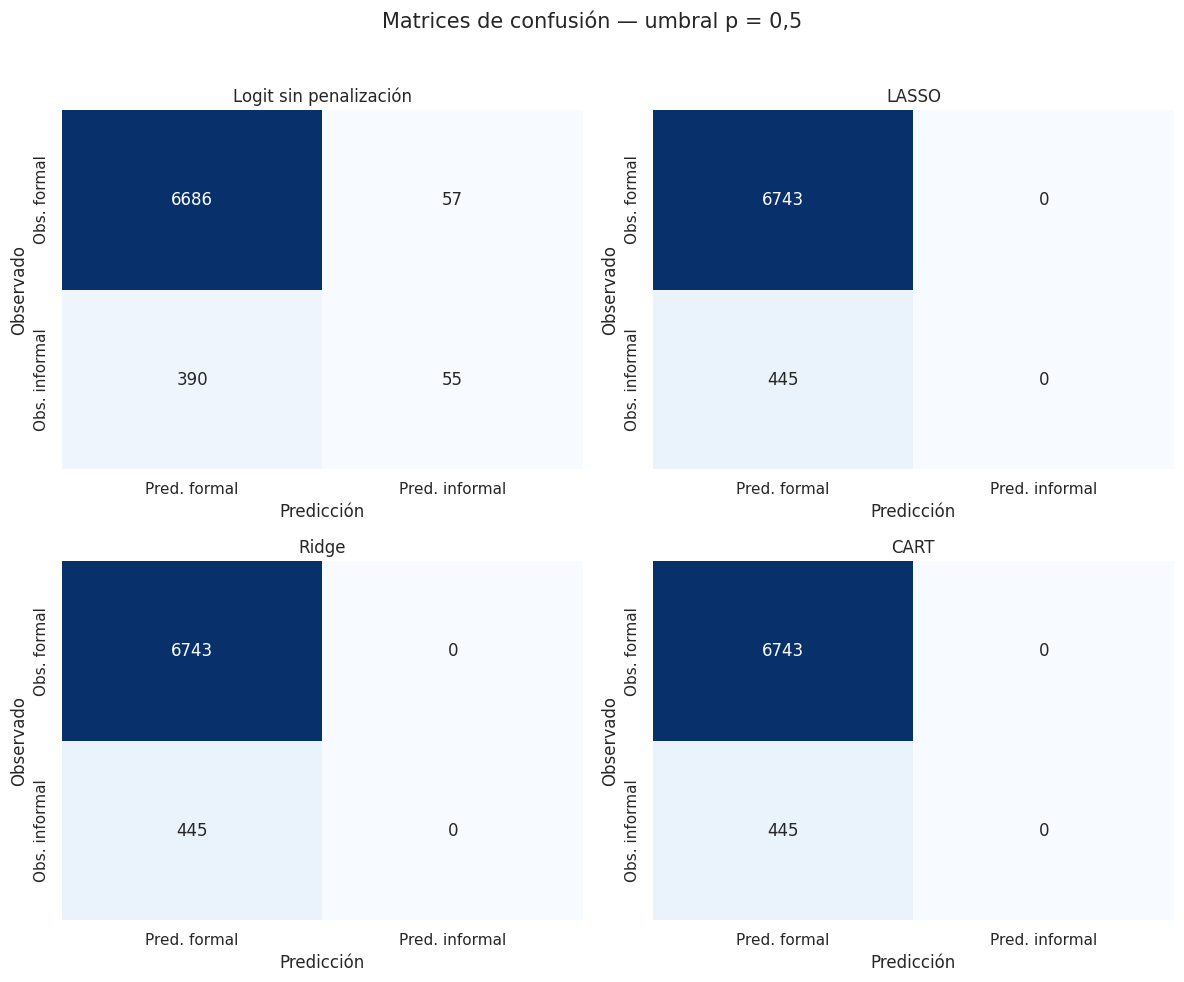

Figura guardada en: /content/drive/MyDrive/taller_de_programacion/salidas_tp4/figuras/Figura_C1_Matrices_Confusion.png


In [46]:
# ============================================================
# Celda 34 - C.1 Matrices de confusión
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(
    2, 2,
    figsize=(12, 10)
)

axes = axes.flatten()

for ax, (nombre, matriz) in zip(
    axes,
    matrices_c1.items()
):

    sns.heatmap(
        matriz,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=ax,
        xticklabels=[
            "Pred. formal",
            "Pred. informal"
        ],
        yticklabels=[
            "Obs. formal",
            "Obs. informal"
        ]
    )

    ax.set_title(nombre)
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Observado")

fig.suptitle(
    "Matrices de confusión — umbral p = 0,5",
    fontsize=15
)

plt.tight_layout(
    rect=[0, 0, 1, 0.96]
)

ruta_figura_c1_matrices = (
    ruta_figuras +
    "Figura_C1_Matrices_Confusion.png"
)

plt.savefig(
    ruta_figura_c1_matrices,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Figura guardada en:",
    ruta_figura_c1_matrices
)

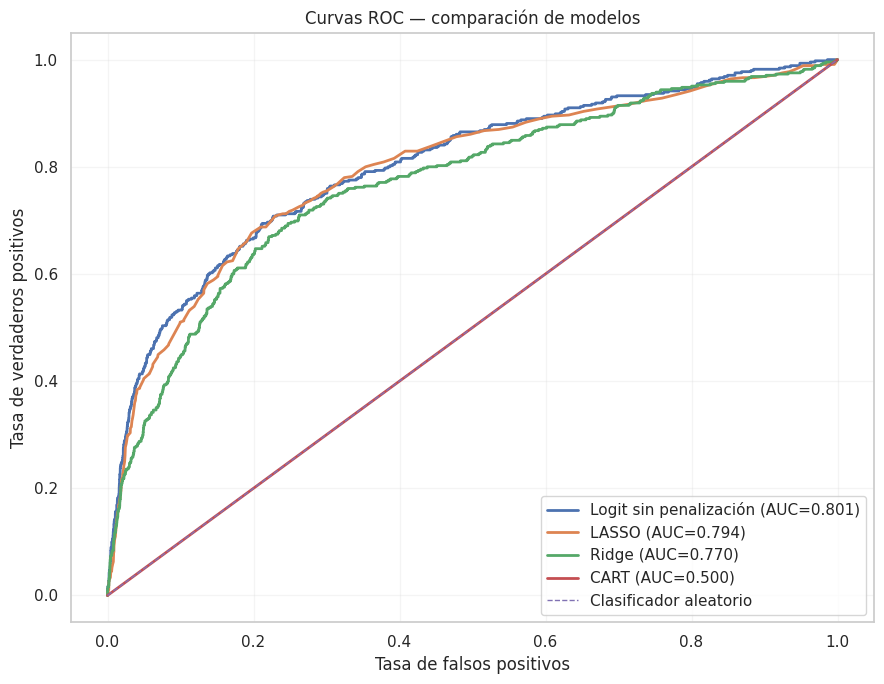

Figura guardada en: /content/drive/MyDrive/taller_de_programacion/salidas_tp4/figuras/Figura_C1_Curvas_ROC.png


In [47]:
# ============================================================
# Celda 35 - C.1 Curvas ROC de los cuatro modelos
# ============================================================

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 7))

for nombre, prob in probabilidades_modelos.items():

    fpr, tpr, _ = roc_curve(
        y_2025_MM,
        prob
    )

    auc = roc_auc_score(
        y_2025_MM,
        prob
    )

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{nombre} (AUC={auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1,
    label="Clasificador aleatorio"
)

plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")

plt.title(
    "Curvas ROC — comparación de modelos"
)

plt.legend(loc="lower right")
plt.grid(alpha=0.20)
plt.tight_layout()

ruta_figura_c1_roc = (
    ruta_figuras +
    "Figura_C1_Curvas_ROC.png"
)

plt.savefig(
    ruta_figura_c1_roc,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Figura guardada en:",
    ruta_figura_c1_roc
)

### C.1. Comparación del desempeño predictivo

La comparación evidencia una consecuencia importante del fuerte desbalance de la variable objetivo. Con un umbral de clasificación de $p=0,5$, el logit sin penalización es el único modelo que identifica trabajadores informales: clasifica correctamente 55 de los 445 casos informales, con un recall de 0,1236 y un F1-score de 0,1975. A cambio, genera 57 falsos positivos y presenta una accuracy de 0,9378, equivalente a un error de clasificación ($1-\mathrm{accuracy}$) de 0,0622.

LASSO, Ridge y el CART seleccionado mediante validación cruzada presentan una accuracy ligeramente superior (0,9381) y un error de clasificación ligeramente inferior (0,0619). Sin embargo, esta aparente mejora se obtiene clasificando todas las observaciones como formales: los tres modelos presentan 445 falsos negativos, ningún verdadero positivo, recall igual a cero y F1-score igual a cero.

Las curvas ROC permiten distinguir el desempeño de clasificación a un umbral específico de la capacidad general de discriminación. El logit sin penalización obtiene el mayor AUC (0,8015), seguido por LASSO (0,7944) y Ridge (0,7702). Por lo tanto, los modelos regularizados conservan capacidad para ordenar a los individuos según su riesgo de informalidad, aun cuando el umbral de 0,5 no permita identificar casos positivos. El CART seleccionado, en cambio, presenta un AUC de 0,5000 debido a que la poda elegida por mínimo error de clasificación reduce el árbol a un único nodo.

Estos resultados muestran que, ante una clase minoritaria, minimizar exclusivamente el error de clasificación puede favorecer soluciones excesivamente conservadoras que reproducen la categoría mayoritaria y pierden capacidad para identificar al grupo de interés.

### C.2. Comunicación, performance predictiva y no linealidad

Existe un trade-off entre simplicidad de comunicación y performance predictiva. LASSO ofrece una representación especialmente parsimoniosa al conservar únicamente tres predictores —`edad`, `tiene_cobertura_salud` e `informal_2024`—, lo que facilita comunicar los principales factores asociados a la informalidad. Sin embargo, con el $\lambda_{CV}$ seleccionado mediante error de clasificación y un umbral de 0,5, no identifica ningún trabajador informal.

El logit sin penalización utiliza todos los predictores y es menos parsimonioso, pero presenta el mayor AUC y es el único de los cuatro modelos que identifica casos informales al umbral solicitado. Ridge ocupa una posición intermedia en términos de regularización, aunque tampoco identifica positivos con $p=0,5$.

En este ejercicio no se observa una ventaja predictiva del método no lineal CART. El árbol seleccionado por validación cruzada queda completamente podado, presenta AUC=0,50 y no identifica trabajadores informales. El análisis complementario del mejor árbol no degenerado resulta útil para interpretar posibles relaciones no lineales y confirma la relevancia de `informal_2024` y `tiene_cobertura_salud`, pero no modifica el resultado del modelo CART seleccionado por el criterio establecido.

### C.3. Implicancias para la asignación de recursos

La evidencia del TP4 modifica parcialmente la respuesta respecto del modelo preferido para la Secretaría de Trabajo. El TP3 mostró que incorporar el estatus de informalidad del período anterior mejoraba la identificación de trabajadores informales. El TP4 confirma la importancia predictiva de esa persistencia: `informal_2024` es uno de los tres predictores que LASSO conserva y concentra la mayor importancia en el CART complementario.

Sin embargo, los resultados también muestran que seleccionar hiperparámetros únicamente minimizando el error de clasificación puede ser inadecuado para una política focalizada en una población minoritaria. LASSO, Ridge y CART alcanzan un error ligeramente menor que el logit sin penalización, pero lo hacen sin identificar a ningún trabajador informal al umbral de 0,5.

Entre los cuatro modelos evaluados bajo las reglas de la consigna, el logit sin penalización ofrece el mejor compromiso para identificar al grupo vulnerable: presenta el mayor AUC (0,8015) y es el único que genera verdaderos positivos. No obstante, su recall de 0,1236 sigue siendo bajo. Para una aplicación operativa de política pública, donde el costo de omitir a una persona vulnerable puede ser superior al de incluir un falso positivo, la selección del umbral de decisión debería definirse en función de ese costo y de la disponibilidad presupuestaria, en lugar de utilizar automáticamente $p=0,5$.

In [48]:
# ============================================================
# Celda 36 - Tabla final resumida de comparación
# ============================================================

tabla_final_c = tabla_metricas_c1[
    [
        "Modelo",
        "Accuracy",
        "1-Accuracy",
        "Precision",
        "Recall",
        "F1",
        "AUC",
        "Informales_predichos"
    ]
].copy()

tabla_final_c = tabla_final_c.round(4)

display(tabla_final_c)

tabla_final_c.to_excel(
    ruta_tablas + "Tabla_C_Comparacion_Final.xlsx",
    index=False
)

print("Tabla final de comparación guardada.")

,Modelo,Accuracy,1-Accuracy,Precision,Recall,F1,AUC,Informales_predichos
0,Logit sin penalización,0.9378,0.0622,0.4911,0.1236,0.1975,0.8015,112
1,LASSO,0.9381,0.0619,0.0000,0.0000,0.0000,0.7944,0
2,Ridge,0.9381,0.0619,0.0000,0.0000,0.0000,0.7702,0
3,CART,0.9381,0.0619,0.0000,0.0000,0.0000,0.5000,0


Tabla final de comparación guardada.


In [49]:
# ============================================================
# Celda 37 - Exportación de bases y resultados TP4
# ============================================================

import os
import pandas as pd

# ------------------------------------------------------------
# Carpetas de salida
# ------------------------------------------------------------

ruta_bases = ruta_salidas + "bases/"

os.makedirs(ruta_bases, exist_ok=True)
os.makedirs(ruta_tablas, exist_ok=True)
os.makedirs(ruta_figuras, exist_ok=True)

# ------------------------------------------------------------
# 1. Base final utilizada en TP4
# ------------------------------------------------------------

base_tp4_final = ocupados_X_2025_MM.copy()
base_tp4_final["informal_2025"] = y_2025_MM.values

base_tp4_final.to_excel(
    ruta_bases + "TP4_Base_Modelado_2025_MM.xlsx",
    index=False
)

base_tp4_final.to_csv(
    ruta_bases + "TP4_Base_Modelado_2025_MM.csv",
    index=False
)

# ------------------------------------------------------------
# 2. Coeficientes Logit / LASSO / Ridge
# ------------------------------------------------------------

tabla_coeficientes_a3.to_excel(
    ruta_tablas + "TP4_Coeficientes_Logit_LASSO_Ridge.xlsx"
)

# ------------------------------------------------------------
# 3. CV Ridge y LASSO
# ------------------------------------------------------------

resumen_cv.to_excel(
    ruta_tablas + "TP4_CV_LASSO_Ridge.xlsx",
    index=False
)

resultados_cv.to_excel(
    ruta_tablas + "TP4_CV_LASSO_Ridge_Folds.xlsx",
    index=False
)

# ------------------------------------------------------------
# 4. CV CART
# ------------------------------------------------------------

resumen_cart_cv.to_excel(
    ruta_tablas + "TP4_CV_CART.xlsx",
    index=False
)

# ------------------------------------------------------------
# 5. Importancia CART
# ------------------------------------------------------------

importancias_no_deg.to_excel(
    ruta_tablas + "TP4_Importancia_CART_Sensibilidad.xlsx",
    index=False
)

# ------------------------------------------------------------
# 6. Comparación final de modelos
# ------------------------------------------------------------

tabla_final_c.to_excel(
    ruta_tablas + "TP4_Comparacion_Final_Modelos.xlsx",
    index=False
)

print("Exportación TP4 completada.")
print("Bases:", ruta_bases)
print("Tablas:", ruta_tablas)
print("Figuras:", ruta_figuras)

Exportación TP4 completada.
Bases: /content/drive/MyDrive/taller_de_programacion/salidas_tp4/bases/
Tablas: /content/drive/MyDrive/taller_de_programacion/salidas_tp4/tablas/
Figuras: /content/drive/MyDrive/taller_de_programacion/salidas_tp4/figuras/


## D. Herramientas de Inteligencia Artificial y reflexión final

Durante el desarrollo del TP4 se utilizaron herramientas de Inteligencia Artificial como apoyo para la programación, revisión metodológica, depuración de código e interpretación de resultados.

La IA se utilizó principalmente para:
- revisar la continuidad metodológica entre TP3 y TP4;
- estructurar y depurar las celdas de preparación de datos;
- implementar Ridge, LASSO y CART;
- verificar la selección de hiperparámetros mediante validación cruzada;
- interpretar los efectos del desbalance de clases;
- organizar tablas, figuras y resultados para la entrega final.

Las decisiones metodológicas y la interpretación final fueron revisadas y discutidas por el grupo.

### D.1. Reflexión sobre el uso de IA

La Inteligencia Artificial fue especialmente útil para estructurar y depurar el código, verificar la implementación de la regularización y la validación cruzada, y detectar problemas metodológicos que no resultaban evidentes a primera vista. En particular, permitió identificar que la selección de hiperparámetros basada exclusivamente en el error de clasificación favorecía modelos que clasificaban a todos los individuos como formales debido al fuerte desbalance de la muestra. También fue útil para interpretar la diferencia entre accuracy, recall, F1-score y AUC. Su aporte fue menos directo en las decisiones sustantivas, ya que la selección de variables, la definición de informalidad y la interpretación económica requirieron mantener consistencia con los TP anteriores y con las indicaciones de clase. En síntesis, la IA funcionó principalmente como herramienta de apoyo técnico y de revisión, más que como sustituto del criterio económico y metodológico del grupo.

### D.2. Tiempo total dedicado

Tiempo total aproximado dedicado a la realización del TP4: **12 horas**.